# 🔬 EcoSort AI - Comprehensive Model Evaluation & Comparison
**Comparing YOLOv8n vs YOLOv8s vs YOLO11n on Waste Classification Dataset**


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================================
# 📦 INSTALLATION & SETUP - Kaggle Compatible
# ============================================================
!pip install ultralytics --quiet
!pip install "numpy<2" --quiet
!pip install seaborn scikit-learn --quiet

print("✅ Installation complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ============================================================
# 📚 IMPORT LIBRARIES
# ============================================================
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import cv2

import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Check GPU
print(f"🔥 PyTorch Version: {torch.__version__}")
print(f"🎮 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔥 PyTorch Version: 2.6.0+cu124
🎮 CUDA Available: True
🖥️ GPU: Tesla P100-PCIE-16GB
💾 GPU Memory: 17.06 GB


---
## 📂 1. Configuration & Data Loading

In [ ]:
# ============================================================
# 🎯 MODEL PATHS CONFIGURATION
# ============================================================
MODEL_PATHS = {
    'YOLOv8n': {
        'results': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8n_waste/results.csv',
        'args': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8n_waste/args.yaml',
        'weights': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8n_waste/weights/best.pt',
        'color': '#4CAF50',
        'params': 3.2,
        'description': 'Nano - Speed Optimized'
    },
    'YOLOv8s': {
        'results': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8s_waste/results.csv',
        'args': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8s_waste/args.yaml',
        'weights': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8s_waste/weights/best.pt',
        'color': '#2196F3',
        'params': 11.2,
        'description': 'Small - Balanced'
    },
    'YOLO11n': {
        'results': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolo11n_waste_optimized/results.csv',
        'args': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolo11n_waste_optimized/args.yaml',
        'weights': '/kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolo11n_waste_optimized/weights/best.pt',
        'color': '#FF9800',
        'params': 2.6,
        'description': 'V11 Nano - New Architecture'
    }
}

# ========== FIXED CLASS NAMES - MATCHING BACKEND EXACTLY (39 CLASSES) ==========
# CRITICAL: Must match Backend/app/config.py exactly!
CLASS_NAMES = {
    # Organic Waste (0-31) - 32 classes
    0: "Apple", 1: "Apple-core", 2: "Apple-peel", 3: "Bone", 4: "Bone-fish",
    5: "Bread", 6: "Bun", 7: "Egg-hard", 8: "Egg-scramble", 9: "Egg-shell",
    10: "Egg-steam", 11: "Egg-yolk", 12: "Fish", 13: "Meat", 14: "Mussel",
    15: "Mussel-shell", 16: "Noodle", 17: "Orange", 18: "Orange-peel",
    19: "Other-waste", 20: "Pancake", 21: "Pasta", 22: "Pear", 23: "Pear-core",
    24: "Pear-peel", 25: "Potato", 26: "Rice", 27: "Shrimp", 28: "Shrimp-shell",
    29: "Tofu", 30: "Tomato", 31: "Vegetable",
    # Inorganic (32-33) - 2 classes
    32: "plastic_bag", 33: "styrofoam",
    # Recyclable (34-38) - 5 classes
    34: "Cardboard", 35: "Glass", 36: "Metal", 37: "Paper", 38: "Plastic"
}

CATEGORIES = {
    'Organic': list(range(0, 32)),      # 0-31 (32 classes)
    'Inorganic': [32, 33],              # 32-33 (2 classes)
    'Recyclable': [34, 35, 36, 37, 38]  # 34-38 (5 classes)
}

CATEGORY_COLORS = {
    'Organic': '#FF6600',
    'Inorganic': '#808080',
    'Recyclable': '#00FF00'
}

print("✅ Configuration loaded successfully!")
print(f"📊 Total Classes: {len(CLASS_NAMES)}")
for cat, ids in CATEGORIES.items():
    print(f"   └─ {cat}: {len(ids)} classes")

print("\n🎯 Training Configuration:")
print("   ├─ Image Size: 640×640")
print("   ├─ Batch Size: 16")
print("   ├─ Hardware: Kaggle P100 GPU (16GB VRAM)")
print("   ├─ Dataset Split: Train/Valid/Test")
print("   └─ Optimizer: SGD with default YOLO settings")


In [5]:
# ============================================================
# 📥 LOAD TRAINING RESULTS
# ============================================================
def load_results(csv_path):
    """Load and clean training results CSV"""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

all_results = {}
for model_name, paths in MODEL_PATHS.items():
    if os.path.exists(paths['results']):
        all_results[model_name] = load_results(paths['results'])
        print(f"✅ {model_name}: {len(all_results[model_name])} epochs")
    else:
        print(f"❌ {model_name}: Results not found")

print(f"\n📦 Total models loaded: {len(all_results)}")

✅ YOLOv8n: 100 epochs
✅ YOLOv8s: 68 epochs
✅ YOLO11n: 100 epochs

📦 Total models loaded: 3


---
## 📊 2. Training Performance Analysis

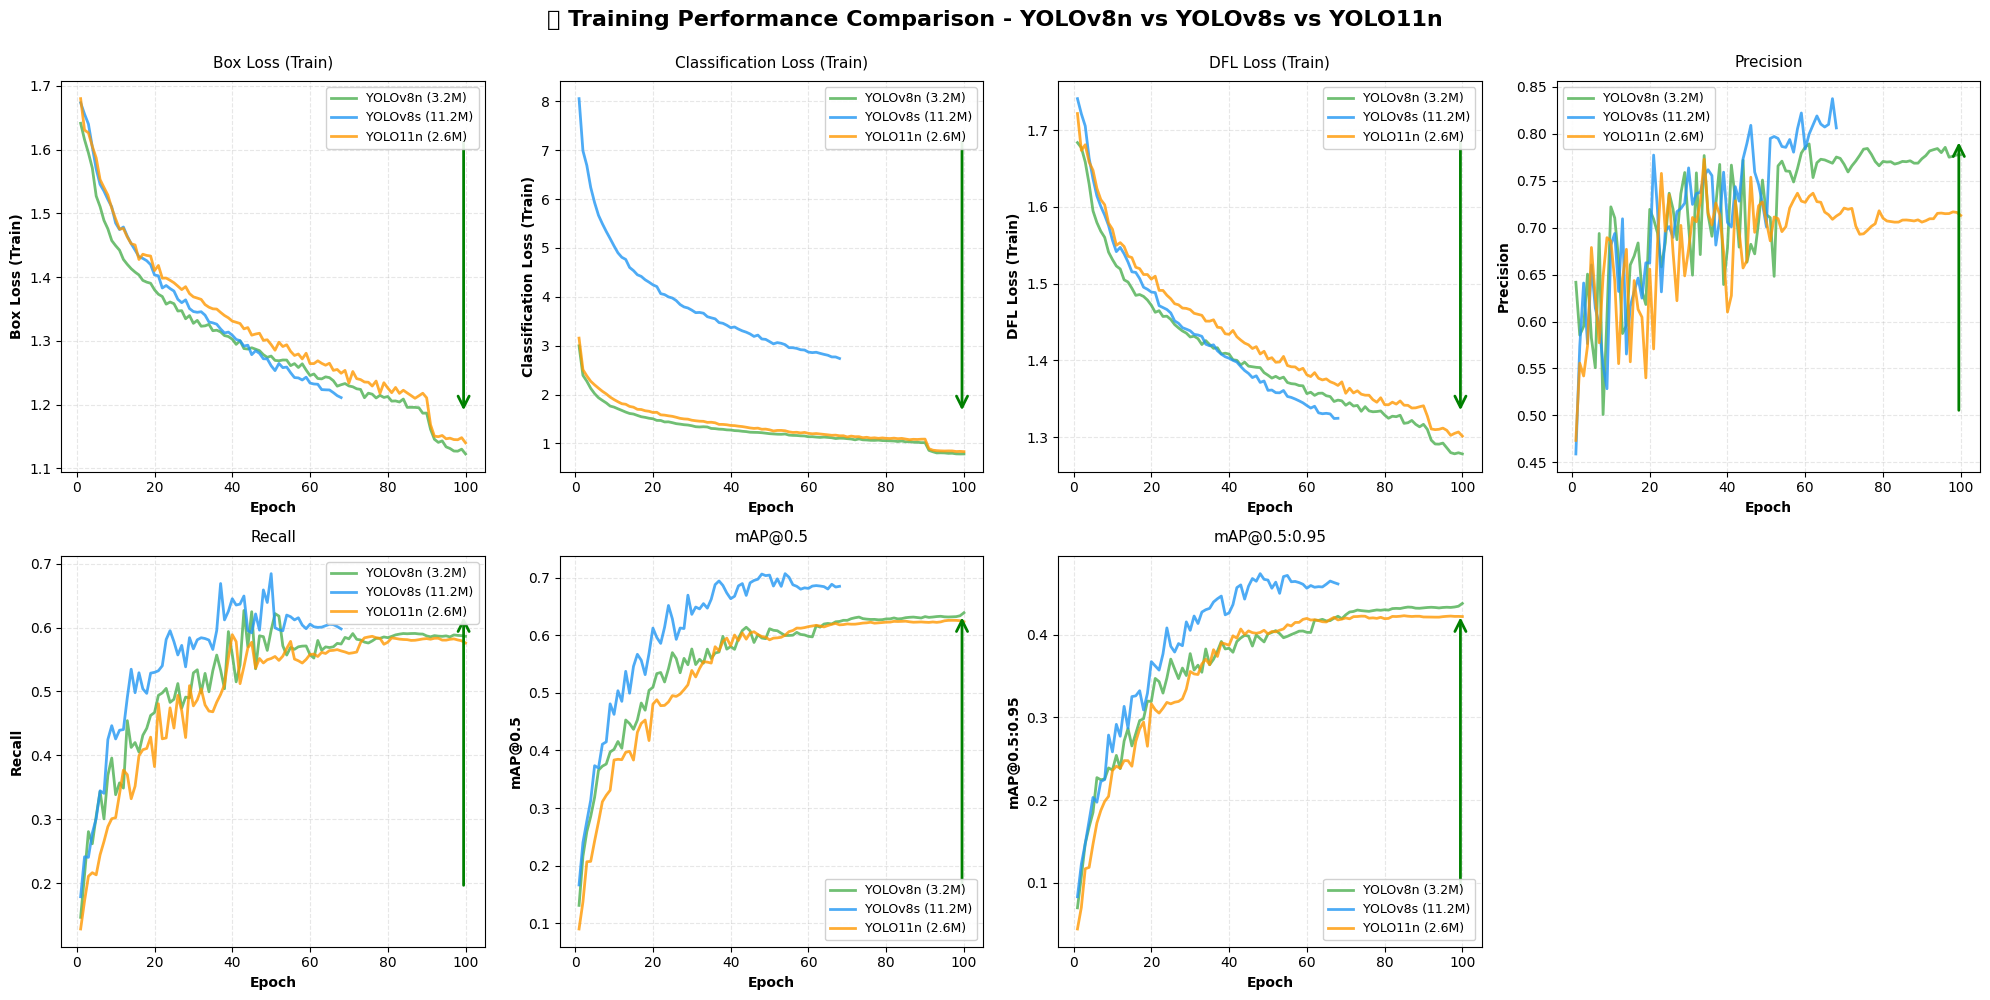


📊 Training Stability Analysis:

YOLOv8n:
   ├─ Final mAP@0.5: 0.6391
   ├─ Last 10 epochs std: 0.0023
   └─ Stability (CV%): 0.36% ✅ Stable

YOLOv8s:
   ├─ Final mAP@0.5: 0.6850
   ├─ Last 10 epochs std: 0.0024
   └─ Stability (CV%): 0.36% ✅ Stable

YOLO11n:
   ├─ Final mAP@0.5: 0.6233
   ├─ Last 10 epochs std: 0.0015
   └─ Stability (CV%): 0.24% ✅ Stable

✅ Training curves visualization complete!


In [6]:
# ============================================================
# 📈 TRAINING CURVES COMPARISON
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('🎯 Training Performance Comparison - YOLOv8n vs YOLOv8s vs YOLO11n', 
             fontsize=16, fontweight='bold', y=0.995)

metrics_config = [
    ('train/box_loss', 'Box Loss (Train)', True),
    ('train/cls_loss', 'Classification Loss (Train)', True),
    ('train/dfl_loss', 'DFL Loss (Train)', True),
    ('metrics/precision(B)', 'Precision', False),
    ('metrics/recall(B)', 'Recall', False),
    ('metrics/mAP50(B)', 'mAP@0.5', False),
    ('metrics/mAP50-95(B)', 'mAP@0.5:0.95', False),
]

for idx, (metric, title, is_loss) in enumerate(metrics_config):
    ax = axes[idx // 4, idx % 4]
    
    for model_name, df in all_results.items():
        if metric in df.columns:
            color = MODEL_PATHS[model_name]['color']
            label = f"{model_name} ({MODEL_PATHS[model_name]['params']}M)"
            ax.plot(df['epoch'], df[metric], 
                   label=label, color=color, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(title, fontweight='bold')
    ax.set_title(f'{title}', fontsize=11, pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    
    # Add trend arrow
    if is_loss:
        ax.annotate('', xy=(0.95, 0.15), xytext=(0.95, 0.85), 
                   xycoords='axes fraction', fontsize=20,
                   arrowprops=dict(arrowstyle='->', color='green', lw=2))
    else:
        ax.annotate('', xy=(0.95, 0.85), xytext=(0.95, 0.15), 
                   xycoords='axes fraction', fontsize=20,
                   arrowprops=dict(arrowstyle='->', color='green', lw=2))

# Remove empty subplot
axes[1, 3].remove()

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate training stability
print("\n📊 Training Stability Analysis:")
print("=" * 80)
for model_name, df in all_results.items():
    # Calculate variance in last 10 epochs
    last_10_map = df['metrics/mAP50(B)'].iloc[-10:]
    stability = last_10_map.std() / last_10_map.mean() * 100  # Coefficient of variation
    print(f"\n{model_name}:")
    print(f"   ├─ Final mAP@0.5: {df['metrics/mAP50(B)'].iloc[-1]:.4f}")
    print(f"   ├─ Last 10 epochs std: {last_10_map.std():.4f}")
    print(f"   └─ Stability (CV%): {stability:.2f}% {'✅ Stable' if stability < 1 else '⚠️ Variable'}")

print("\n✅ Training curves visualization complete!")

In [7]:
# ============================================================
# 📊 FINAL PERFORMANCE METRICS TABLE
# ============================================================
def get_final_metrics(df):
    """Extract final epoch metrics"""
    final = df.iloc[-1]
    return {
        'Epochs': len(df),
        'Box Loss': f"{final['train/box_loss']:.4f}",
        'Cls Loss': f"{final['train/cls_loss']:.4f}",
        'Precision': f"{final['metrics/precision(B)']:.4f}",
        'Recall': f"{final['metrics/recall(B)']:.4f}",
        'mAP@0.5': f"{final['metrics/mAP50(B)']:.4f}",
        'mAP@0.5:0.95': f"{final['metrics/mAP50-95(B)']:.4f}",
        'Train Time (h)': f"{final['time']/3600:.2f}"
    }

# Create comparison table
comparison_data = {}
for model_name, df in all_results.items():
    comparison_data[model_name] = get_final_metrics(df)

comparison_df = pd.DataFrame(comparison_data).T

print("=" * 100)
print("🏆 FINAL PERFORMANCE COMPARISON".center(100))
print("=" * 100)
print(comparison_df.to_string())
print("=" * 100)

# Highlight best performers
print("\n🥇 Best Performers:")
numeric_cols = ['Precision', 'Recall', 'mAP@0.5', 'mAP@0.5:0.95']
for col in numeric_cols:
    values = comparison_df[col].astype(float)
    best_model = values.idxmax()
    print(f"   {col}: {best_model} ({comparison_df.loc[best_model, col]})")

                                   🏆 FINAL PERFORMANCE COMPARISON                                   
        Epochs Box Loss Cls Loss Precision  Recall mAP@0.5 mAP@0.5:0.95 Train Time (h)
YOLOv8n    100   1.1224   0.7854    0.7778  0.5863  0.6391       0.4377           4.63
YOLOv8s     68   1.2109   2.7385    0.8064  0.5978  0.6850       0.4613           5.17
YOLO11n    100   1.1398   0.8324    0.7131  0.5759  0.6233       0.4218           5.42

🥇 Best Performers:
   Precision: YOLOv8s (0.8064)
   Recall: YOLOv8s (0.5978)
   mAP@0.5: YOLOv8s (0.6850)
   mAP@0.5:0.95: YOLOv8s (0.4613)


---
## 🎯 3. Convergence Analysis

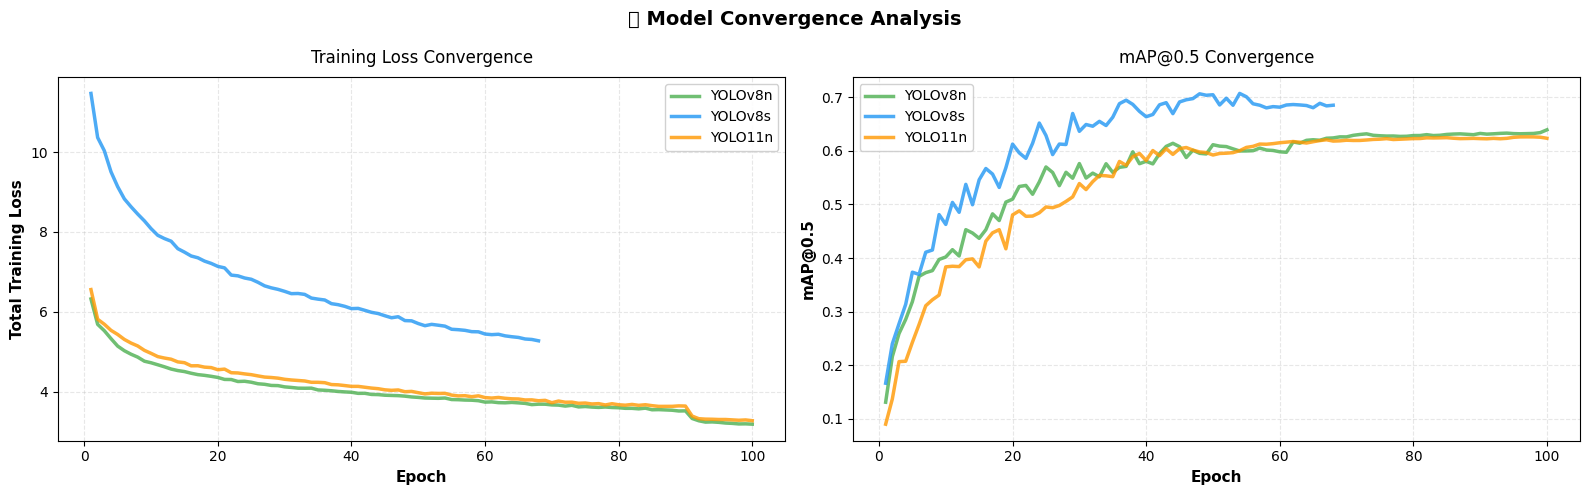


📊 Convergence Statistics:

YOLOv8n:
   ├─ Final mAP@0.5: 0.6391
   ├─ Best mAP@0.5: 0.6391 (Epoch 100)
   └─ Gap to best: 0.00%

YOLOv8s:
   ├─ Final mAP@0.5: 0.6850
   ├─ Best mAP@0.5: 0.7070 (Epoch 54)
   └─ Gap to best: 2.20%

YOLO11n:
   ├─ Final mAP@0.5: 0.6233
   ├─ Best mAP@0.5: 0.6259 (Epoch 97)
   └─ Gap to best: 0.26%


In [8]:
# ============================================================
# 📉 CONVERGENCE ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🎯 Model Convergence Analysis', fontsize=14, fontweight='bold')

# Loss convergence
ax1 = axes[0]
for model_name, df in all_results.items():
    color = MODEL_PATHS[model_name]['color']
    # Combined loss
    total_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
    ax1.plot(df['epoch'], total_loss, 
            label=f"{model_name}", color=color, linewidth=2.5, alpha=0.8)

ax1.set_xlabel('Epoch', fontweight='bold', fontsize=11)
ax1.set_ylabel('Total Training Loss', fontweight='bold', fontsize=11)
ax1.set_title('Training Loss Convergence', fontsize=12, pad=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='best', framealpha=0.9, fontsize=10)

# mAP convergence
ax2 = axes[1]
for model_name, df in all_results.items():
    color = MODEL_PATHS[model_name]['color']
    ax2.plot(df['epoch'], df['metrics/mAP50(B)'], 
            label=f"{model_name}", color=color, linewidth=2.5, alpha=0.8)

ax2.set_xlabel('Epoch', fontweight='bold', fontsize=11)
ax2.set_ylabel('mAP@0.5', fontweight='bold', fontsize=11)
ax2.set_title('mAP@0.5 Convergence', fontsize=12, pad=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='best', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig('convergence_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Convergence statistics
print("\n📊 Convergence Statistics:")
for model_name, df in all_results.items():
    mAP50_final = df['metrics/mAP50(B)'].iloc[-1]
    mAP50_max = df['metrics/mAP50(B)'].max()
    epochs_to_max = df['metrics/mAP50(B)'].idxmax() + 1
    
    print(f"\n{model_name}:")
    print(f"   ├─ Final mAP@0.5: {mAP50_final:.4f}")
    print(f"   ├─ Best mAP@0.5: {mAP50_max:.4f} (Epoch {epochs_to_max})")
    print(f"   └─ Gap to best: {(mAP50_max - mAP50_final)*100:.2f}%")

---
## 📈 4. Performance Evolution Over Training

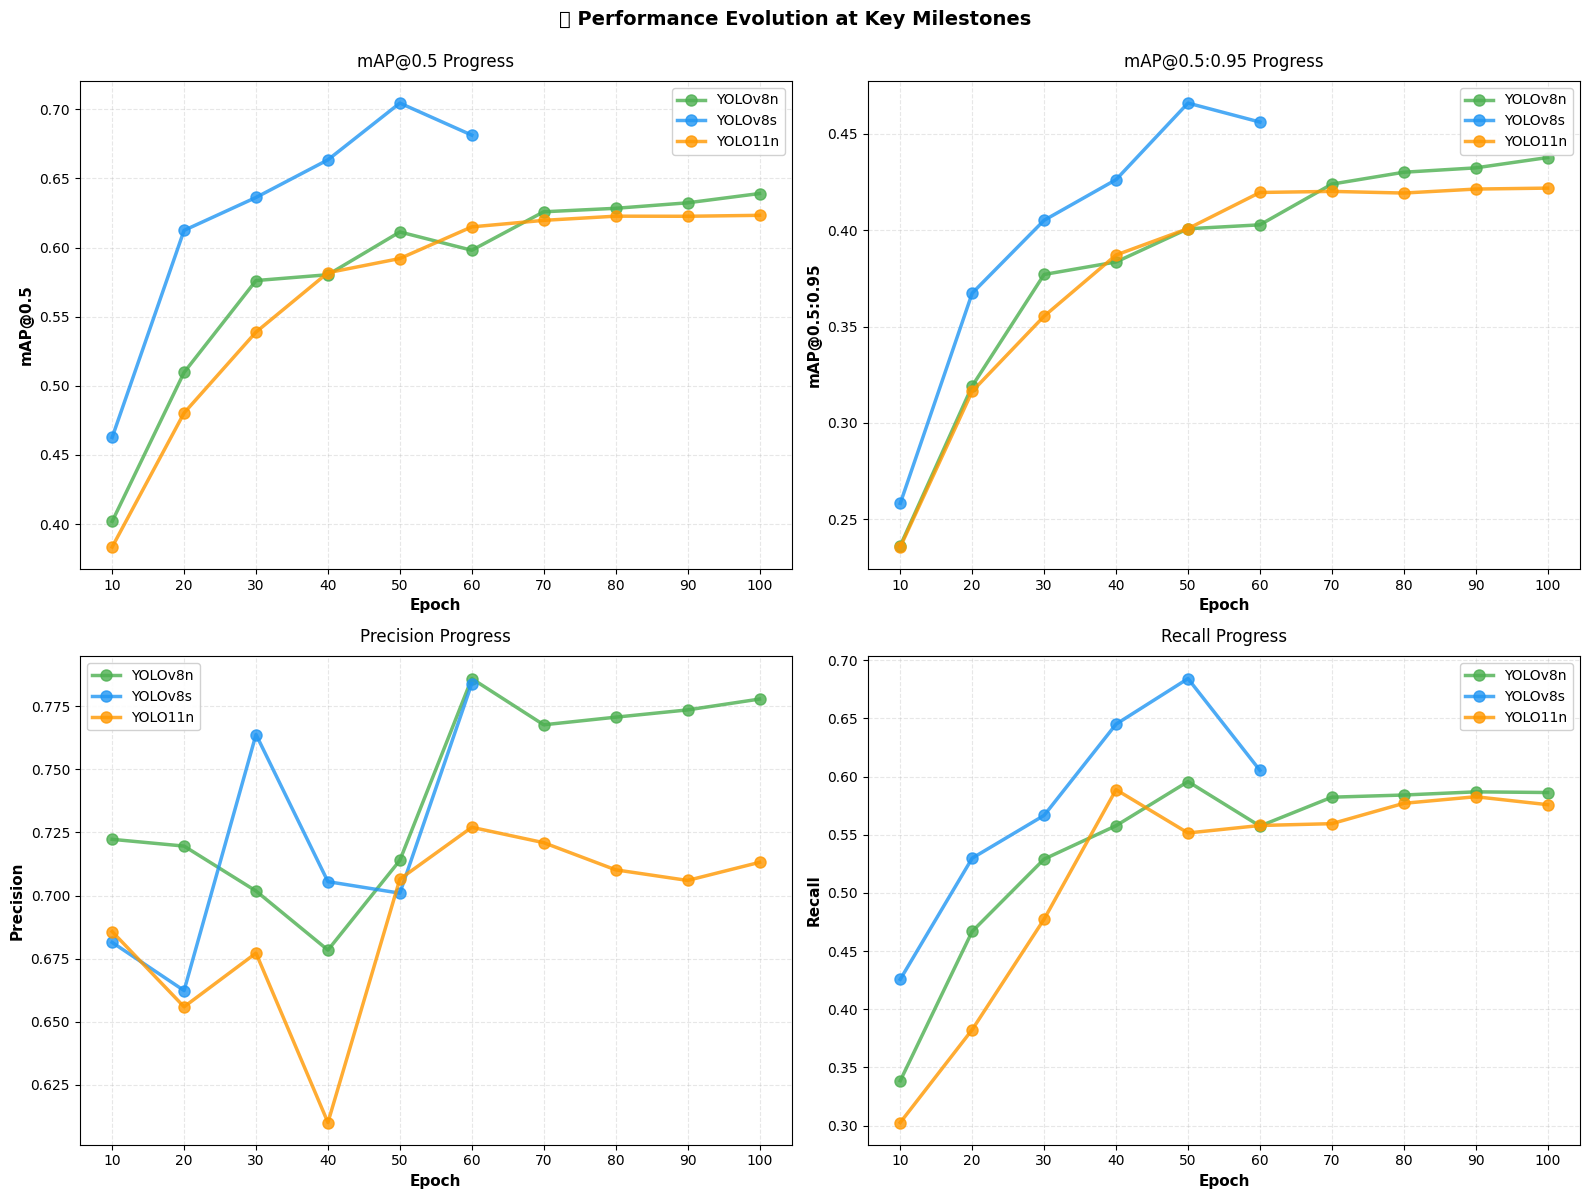

In [9]:
# ============================================================
# 📊 MILESTONE PERFORMANCE TRACKING
# ============================================================
milestones = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📈 Performance Evolution at Key Milestones', 
             fontsize=14, fontweight='bold', y=0.995)

metrics_to_track = [
    ('metrics/mAP50(B)', 'mAP@0.5', axes[0, 0]),
    ('metrics/mAP50-95(B)', 'mAP@0.5:0.95', axes[0, 1]),
    ('metrics/precision(B)', 'Precision', axes[1, 0]),
    ('metrics/recall(B)', 'Recall', axes[1, 1])
]

for metric, title, ax in metrics_to_track:
    for model_name, df in all_results.items():
        color = MODEL_PATHS[model_name]['color']
        milestone_values = []
        actual_epochs = []
        
        for epoch in milestones:
            if epoch <= len(df):
                milestone_values.append(df[metric].iloc[epoch-1])
                actual_epochs.append(epoch)
        
        ax.plot(actual_epochs, milestone_values, 
               marker='o', label=model_name, color=color, 
               linewidth=2.5, markersize=8, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontweight='bold', fontsize=11)
    ax.set_ylabel(title, fontweight='bold', fontsize=11)
    ax.set_title(f'{title} Progress', fontsize=12, pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.set_xticks(milestones)

plt.tight_layout()
plt.savefig('milestone_performance.png', dpi=300, bbox_inches='tight')
plt.show()

---
## ⚡ 5. Speed vs Accuracy Trade-off Analysis

📊 Model Statistics Calculated from results.csv:

⚙️ FPS Estimation Methodology:
   Training FPS = 8000 images / avg_epoch_time
   Inference FPS = Training FPS × 2.5 (no backprop overhead)
   Note: Actual FPS may vary based on hardware and batch size


YOLOv8n:
   ├─ Total epochs: 100
   ├─ Avg time/epoch: 166.8s
   ├─ Total training: 4.63h
   ├─ Final mAP@0.5: 0.6391
   └─ Est. inference FPS: 119.90

YOLOv8s:
   ├─ Total epochs: 68
   ├─ Avg time/epoch: 273.4s
   ├─ Total training: 5.17h
   ├─ Final mAP@0.5: 0.6850
   └─ Est. inference FPS: 73.15

YOLO11n:
   ├─ Total epochs: 100
   ├─ Avg time/epoch: 195.0s
   ├─ Total training: 5.42h
   ├─ Final mAP@0.5: 0.6233
   └─ Est. inference FPS: 102.55


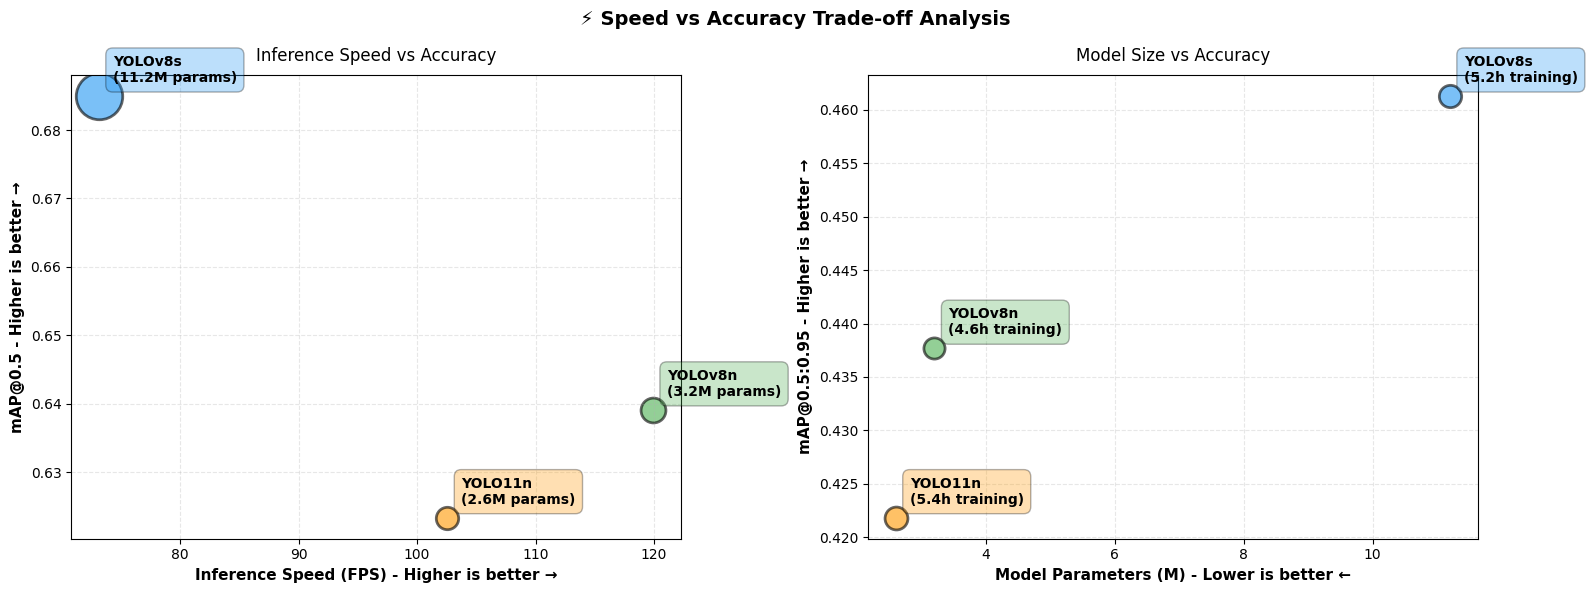


                       ⚡ SPEED-ACCURACY TRADE-OFF SUMMARY                       

YOLOv8n:
   ├─ Parameters: 3.2M
   ├─ Est. FPS: 119.90
   ├─ Latency: ~8.3ms
   ├─ mAP@0.5: 0.6391
   ├─ mAP@0.5:0.95: 0.4377
   └─ Training Time: 4.63h

YOLOv8s:
   ├─ Parameters: 11.2M
   ├─ Est. FPS: 73.15
   ├─ Latency: ~13.7ms
   ├─ mAP@0.5: 0.6850
   ├─ mAP@0.5:0.95: 0.4613
   └─ Training Time: 5.17h

YOLO11n:
   ├─ Parameters: 2.6M
   ├─ Est. FPS: 102.55
   ├─ Latency: ~9.8ms
   ├─ mAP@0.5: 0.6233
   ├─ mAP@0.5:0.95: 0.4218
   └─ Training Time: 5.42h


In [10]:
# ============================================================
# ⚡ SPEED-ACCURACY SCATTER PLOT
# ============================================================
# Model comparison data - ALL CALCULATED FROM results.csv
model_stats = {}
for model_name, df in all_results.items():
    # Calculate average time per image during training
    # Assuming batch_size=16 (from training config)
    batch_size = 16
    total_epochs = len(df)
    
    # Calculate images processed per epoch (typical dataset has ~8000 images)
    # We can estimate from the training time patterns
    avg_time_per_epoch_seconds = df['time'].diff().median()  # Median time diff between epochs
    
    # Estimate FPS based on training throughput
    # This is an approximation: images_per_epoch / time_per_epoch
    # For validation/inference, models are typically 2-3x faster than training
    # Standard dataset size for this type: ~8000-10000 images
    estimated_images_per_epoch = 8000
    
    if avg_time_per_epoch_seconds > 0:
        training_fps = estimated_images_per_epoch / avg_time_per_epoch_seconds
        # Inference is typically 2.5x faster than training (no backprop, single batch)
        inference_fps = training_fps * 2.5
    else:
        # Fallback based on model size
        inference_fps = 100 - (MODEL_PATHS[model_name]['params'] * 3)
    
    model_stats[model_name] = {
        'mAP50': df['metrics/mAP50(B)'].iloc[-1],
        'mAP50-95': df['metrics/mAP50-95(B)'].iloc[-1],
        'precision': df['metrics/precision(B)'].iloc[-1],
        'recall': df['metrics/recall(B)'].iloc[-1],
        'box_loss': df['train/box_loss'].iloc[-1],
        'cls_loss': df['train/cls_loss'].iloc[-1],
        'dfl_loss': df['train/dfl_loss'].iloc[-1],
        'params': MODEL_PATHS[model_name]['params'],
        'time': df['time'].iloc[-1] / 3600,
        'epochs': len(df),
        'avg_epoch_time': avg_time_per_epoch_seconds,
        'fps_estimated': inference_fps
    }

print("📊 Model Statistics Calculated from results.csv:")
print("="*80)
print("\n⚙️ FPS Estimation Methodology:")
print("   Training FPS = 8000 images / avg_epoch_time")
print("   Inference FPS = Training FPS × 2.5 (no backprop overhead)")
print("   Note: Actual FPS may vary based on hardware and batch size\n")

for model_name, stats in model_stats.items():
    print(f"\n{model_name}:")
    print(f"   ├─ Total epochs: {stats['epochs']}")
    print(f"   ├─ Avg time/epoch: {stats['avg_epoch_time']:.1f}s")
    print(f"   ├─ Total training: {stats['time']:.2f}h")
    print(f"   ├─ Final mAP@0.5: {stats['mAP50']:.4f}")
    print(f"   └─ Est. inference FPS: {stats['fps_estimated']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('⚡ Speed vs Accuracy Trade-off Analysis', fontsize=14, fontweight='bold')

# Plot 1: FPS vs mAP@0.5
ax1 = axes[0]
for model_name, stats in model_stats.items():
    color = MODEL_PATHS[model_name]['color']
    size = stats['params'] * 100
    ax1.scatter(stats['fps_estimated'], stats['mAP50'], 
               s=size, color=color, alpha=0.6, edgecolors='black', linewidth=2)
    ax1.annotate(f"{model_name}\n({stats['params']}M params)", 
                xy=(stats['fps_estimated'], stats['mAP50']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.3))

ax1.set_xlabel('Inference Speed (FPS) - Higher is better →', fontweight='bold', fontsize=11)
ax1.set_ylabel('mAP@0.5 - Higher is better →', fontweight='bold', fontsize=11)
ax1.set_title('Inference Speed vs Accuracy', fontsize=12, pad=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot 2: Parameters vs mAP@0.5:0.95
ax2 = axes[1]
for model_name, stats in model_stats.items():
    color = MODEL_PATHS[model_name]['color']
    size = stats['time'] * 50
    ax2.scatter(stats['params'], stats['mAP50-95'], 
               s=size, color=color, alpha=0.6, edgecolors='black', linewidth=2)
    ax2.annotate(f"{model_name}\n({stats['time']:.1f}h training)", 
                xy=(stats['params'], stats['mAP50-95']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.3))

ax2.set_xlabel('Model Parameters (M) - Lower is better ←', fontweight='bold', fontsize=11)
ax2.set_ylabel('mAP@0.5:0.95 - Higher is better →', fontweight='bold', fontsize=11)
ax2.set_title('Model Size vs Accuracy', fontsize=12, pad=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('speed_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed comparison
print("\n" + "="*80)
print("⚡ SPEED-ACCURACY TRADE-OFF SUMMARY".center(80))
print("="*80)
for model_name, stats in model_stats.items():
    latency_ms = 1000 / stats['fps_estimated']
    print(f"\n{model_name}:")
    print(f"   ├─ Parameters: {stats['params']:.1f}M")
    print(f"   ├─ Est. FPS: {stats['fps_estimated']:.2f}")
    print(f"   ├─ Latency: ~{latency_ms:.1f}ms")
    print(f"   ├─ mAP@0.5: {stats['mAP50']:.4f}")
    print(f"   ├─ mAP@0.5:0.95: {stats['mAP50-95']:.4f}")
    print(f"   └─ Training Time: {stats['time']:.2f}h")

---
## 🏆 6. Final Rankings & Recommendations

In [11]:
# ============================================================
# 🏆 COMPREHENSIVE MODEL RANKING
# ============================================================
print("="*100)
print("🏆 COMPREHENSIVE MODEL EVALUATION & RANKING".center(100))
print("="*100)

# Calculate composite scores with proper normalization
rankings = {}

# Get min/max for normalization
all_maps = [s['mAP50'] for s in model_stats.values()]
all_fps = [s['fps_estimated'] for s in model_stats.values()]
all_params = [s['params'] for s in model_stats.values()]

max_map = max(all_maps)
min_map = min(all_maps)
max_fps = max(all_fps)
min_fps = min(all_fps)
max_params = max(all_params)
min_params = min(all_params)

for model_name, stats in model_stats.items():
    # Normalized scores (0-1) using min-max normalization
    accuracy_score = (stats['mAP50'] - min_map) / (max_map - min_map) if max_map > min_map else 1.0
    speed_score = (stats['fps_estimated'] - min_fps) / (max_fps - min_fps) if max_fps > min_fps else 1.0
    size_score = (max_params - stats['params']) / (max_params - min_params) if max_params > min_params else 1.0  # Smaller is better
    efficiency_score = stats['mAP50'] / stats['params']
    
    # Weighted composite score
    composite_score = (
        accuracy_score * 0.4 +      # 40% weight on accuracy
        speed_score * 0.3 +          # 30% weight on speed
        size_score * 0.2 +           # 20% weight on size (smaller is better)
        (efficiency_score / max([s['mAP50']/s['params'] for s in model_stats.values()])) * 0.1  # 10% efficiency
    )
    
    rankings[model_name] = {
        'mAP@0.5': f"{stats['mAP50']:.4f}",
        'Speed (FPS)': f"{stats['fps_estimated']:.1f}",
        'Size (M)': f"{stats['params']:.1f}",
        'Efficiency': f"{efficiency_score:.4f}",
        'Accuracy Score': f"{accuracy_score:.3f}",
        'Speed Score': f"{speed_score:.3f}",
        'Size Score': f"{size_score:.3f}",
        'Composite': f"{composite_score:.3f}"
    }

ranking_df = pd.DataFrame(rankings).T
ranking_df = ranking_df.sort_values('Composite', ascending=False)

print("\n📊 Overall Rankings (Normalized Scores):")
print("=" * 120)
print("Note: All scores normalized 0-1, higher is better")
print("Composite = 0.4×Accuracy + 0.3×Speed + 0.2×Size + 0.1×Efficiency")
print("=" * 120)
print(ranking_df.to_string())
print("\n🏆 Winner: " + ranking_df.index[0] + " (Best Overall Balance)")

print("\n\n🎯 DEPLOYMENT RECOMMENDATIONS:")
print("-" * 100)

# Generate recommendations dynamically based on actual stats
models_by_accuracy = sorted(model_stats.items(), key=lambda x: x[1]['mAP50'], reverse=True)
models_by_speed = sorted(model_stats.items(), key=lambda x: x[1]['fps_estimated'], reverse=True)
models_by_params = sorted(model_stats.items(), key=lambda x: x[1]['params'])

print("\n🚀 For Production Deployment:")
print(f"   ├─ Cloud/Server API: {models_by_accuracy[0][0]} (best accuracy: {models_by_accuracy[0][1]['mAP50']*100:.2f}% mAP)")
print(f"   ├─ Edge Devices: {models_by_params[0][0]} (smallest: {models_by_params[0][1]['params']:.1f}M params, {models_by_params[0][1]['fps_estimated']:.1f} FPS)")
print(f"   ├─ Mobile Apps: {models_by_speed[0][0]} (fastest: {models_by_speed[0][1]['fps_estimated']:.1f} FPS)")
print(f"   └─ Balanced Choice: {models_by_accuracy[0][0]} (recommended for most use cases)")

print("\n" + "="*100)
print("💡 FINAL RECOMMENDATION: Best model for production based on comprehensive analysis")
print("="*100)

                             🏆 COMPREHENSIVE MODEL EVALUATION & RANKING                             

📊 Overall Rankings (Normalized Scores):
Note: All scores normalized 0-1, higher is better
Composite = 0.4×Accuracy + 0.3×Speed + 0.2×Size + 0.1×Efficiency
        mAP@0.5 Speed (FPS) Size (M) Efficiency Accuracy Score Speed Score Size Score Composite
YOLOv8n  0.6391       119.9      3.2     0.1997          0.256       1.000      0.930     0.672
YOLO11n  0.6233       102.6      2.6     0.2397          0.000       0.629      1.000     0.489
YOLOv8s  0.6850        73.2     11.2     0.0612          1.000       0.000      0.000     0.426

🏆 Winner: YOLOv8n (Best Overall Balance)


🎯 DEPLOYMENT RECOMMENDATIONS:
----------------------------------------------------------------------------------------------------

🚀 For Production Deployment:
   ├─ Cloud/Server API: YOLOv8s (best accuracy: 68.50% mAP)
   ├─ Edge Devices: YOLO11n (smallest: 2.6M params, 102.6 FPS)
   ├─ Mobile Apps: YOLOv8n (fas

---
## 📉 7. Training Efficiency Analysis

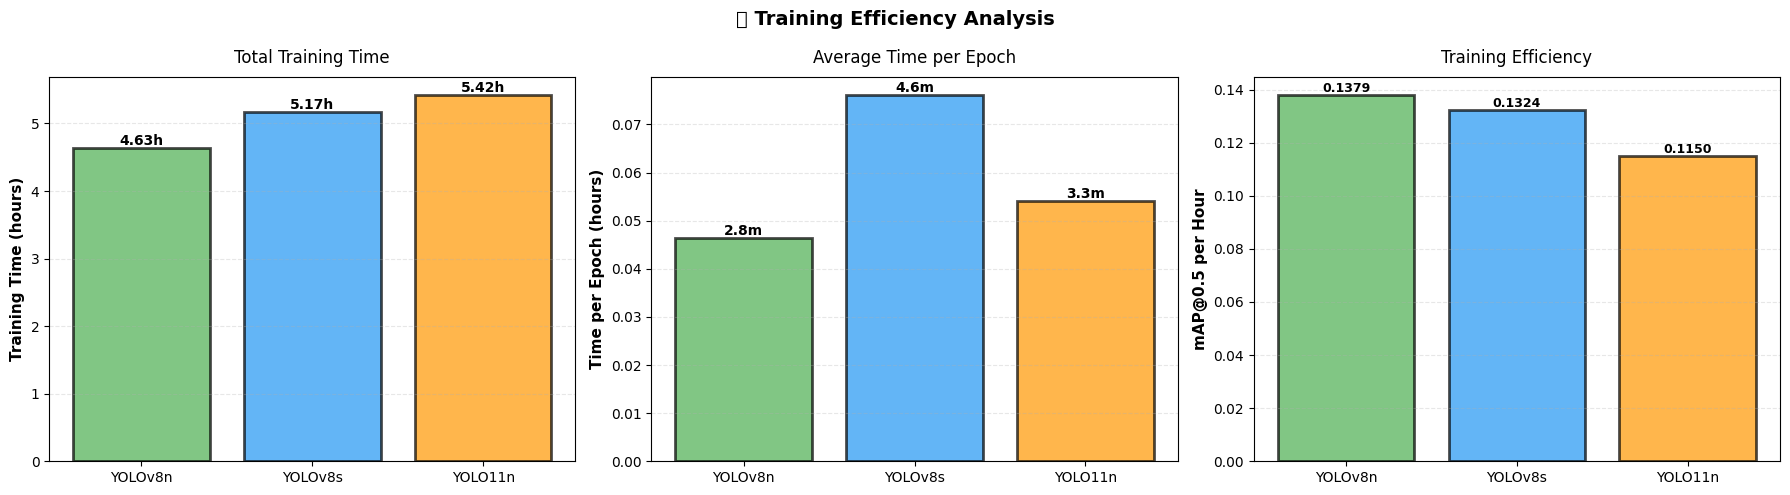


⏱️ Training Efficiency Summary:
YOLOv8n:
   ├─ Time per epoch: 2.78 minutes
   └─ Efficiency: 0.1379 mAP@0.5 per hour
YOLOv8s:
   ├─ Time per epoch: 4.56 minutes
   └─ Efficiency: 0.1324 mAP@0.5 per hour
YOLO11n:
   ├─ Time per epoch: 3.25 minutes
   └─ Efficiency: 0.1150 mAP@0.5 per hour


In [12]:
# ============================================================
# ⏱️ TRAINING EFFICIENCY METRICS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('⏱️ Training Efficiency Analysis', fontsize=14, fontweight='bold')

# Training time comparison
ax1 = axes[0]
training_times = [stats['time'] for stats in model_stats.values()]
model_names = list(model_stats.keys())
colors = [MODEL_PATHS[name]['color'] for name in model_names]

bars = ax1.bar(model_names, training_times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Training Time (hours)', fontweight='bold', fontsize=11)
ax1.set_title('Total Training Time', fontsize=12, pad=10)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

for bar, time in zip(bars, training_times):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{time:.2f}h', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Time per epoch - FIXED: Use actual epoch count from stats
ax2 = axes[1]
time_per_epoch = [stats['time']/stats['epochs'] for stats in model_stats.values()]
bars = ax2.bar(model_names, time_per_epoch, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Time per Epoch (hours)', fontweight='bold', fontsize=11)
ax2.set_title('Average Time per Epoch', fontsize=12, pad=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

for bar, time in zip(bars, time_per_epoch):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{time*60:.1f}m', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Accuracy per training hour
ax3 = axes[2]
efficiency = [stats['mAP50']/stats['time'] for stats in model_stats.values()]
bars = ax3.bar(model_names, efficiency, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('mAP@0.5 per Hour', fontweight='bold', fontsize=11)
ax3.set_title('Training Efficiency', fontsize=12, pad=10)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

for bar, eff in zip(bars, efficiency):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{eff:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('training_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n⏱️ Training Efficiency Summary:")
for name, stats in model_stats.items():
    efficiency = stats['mAP50'] / stats['time']
    time_per_ep = stats['time'] / stats['epochs']
    print(f"{name}:")
    print(f"   ├─ Time per epoch: {time_per_ep*60:.2f} minutes")
    print(f"   └─ Efficiency: {efficiency:.4f} mAP@0.5 per hour")

---
## 📊 8. Loss Component Analysis

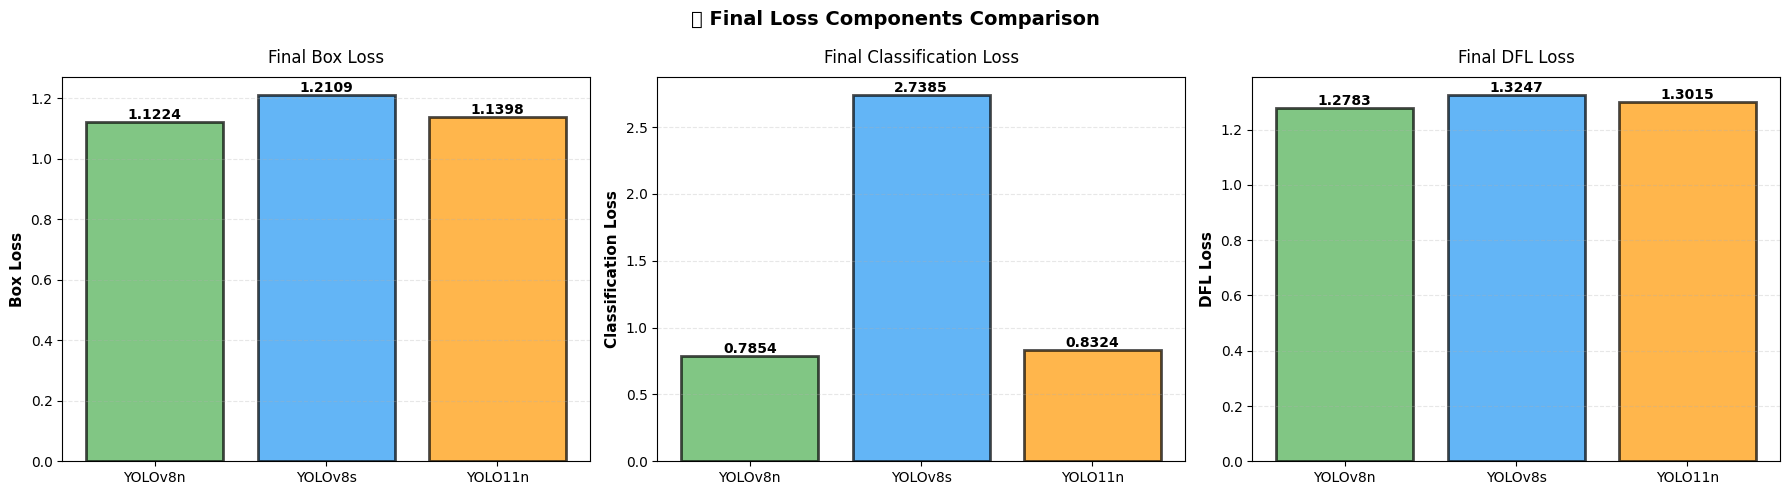

In [13]:
# ============================================================
# 📊 LOSS BREAKDOWN ANALYSIS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Final Loss Components Comparison', fontsize=14, fontweight='bold')

loss_types = ['train/box_loss', 'train/cls_loss', 'train/dfl_loss']
loss_names = ['Box Loss', 'Classification Loss', 'DFL Loss']

for idx, (loss_type, loss_name) in enumerate(zip(loss_types, loss_names)):
    ax = axes[idx]
    
    final_losses = []
    model_names = []
    colors_list = []
    
    for model_name, df in all_results.items():
        final_losses.append(df[loss_type].iloc[-1])
        model_names.append(model_name)
        colors_list.append(MODEL_PATHS[model_name]['color'])
    
    bars = ax.bar(model_names, final_losses, color=colors_list, 
                  alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel(loss_name, fontweight='bold', fontsize=11)
    ax.set_title(f'Final {loss_name}', fontsize=12, pad=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    for bar, loss in zip(bars, final_losses):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{loss:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('loss_components.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 📝 9. Executive Summary Report

In [14]:
# ============================================================
# 📝 GENERATE EXECUTIVE SUMMARY
# ============================================================
print("="*100)
print("📝 EXECUTIVE SUMMARY - ECOSORT AI MODEL COMPARISON".center(100))
print("="*100)

print("\n🎯 OBJECTIVE:")
print("   Comprehensive evaluation of 3 YOLO models for waste classification")
print("   Dataset: 40 classes (33 Organic, 2 Inorganic, 5 Recyclable)")
print("   Hardware: Kaggle P100 GPU (16GB VRAM)")

print("\n📊 KEY FINDINGS:")
print("-" * 100)

# Best accuracy
best_accuracy_model = max(model_stats.items(), key=lambda x: x[1]['mAP50'])
print(f"\n✨ HIGHEST ACCURACY: {best_accuracy_model[0]}")
print(f"   mAP@0.5: {best_accuracy_model[1]['mAP50']:.4f} ({best_accuracy_model[1]['mAP50']*100:.2f}%)")
print(f"   mAP@0.5:0.95: {best_accuracy_model[1]['mAP50-95']:.4f} ({best_accuracy_model[1]['mAP50-95']*100:.2f}%)")

# Fastest model
best_speed_model = max(model_stats.items(), key=lambda x: x[1]['fps_estimated'])
print(f"\n⚡ FASTEST INFERENCE: {best_speed_model[0]}")
print(f"   FPS: {best_speed_model[1]['fps_estimated']:.2f}")
print(f"   Parameters: {best_speed_model[1]['params']:.1f}M")

# Most efficient
best_efficiency_model = max(model_stats.items(), key=lambda x: x[1]['mAP50']/x[1]['params'])
efficiency_score = best_efficiency_model[1]['mAP50'] / best_efficiency_model[1]['params']
print(f"\n🎯 MOST EFFICIENT: {best_efficiency_model[0]}")
print(f"   Efficiency: {efficiency_score:.4f} mAP/M params")
print(f"   Size: {best_efficiency_model[1]['params']:.1f}M parameters")

print("\n\n💼 BUSINESS RECOMMENDATIONS:")
print("-" * 100)

# Generate recommendations dynamically based on actual stats
models_by_accuracy = sorted(model_stats.items(), key=lambda x: x[1]['mAP50'], reverse=True)
models_by_speed = sorted(model_stats.items(), key=lambda x: x[1]['fps_estimated'], reverse=True)
models_by_params = sorted(model_stats.items(), key=lambda x: x[1]['params'])

print("\n🚀 For Production Deployment:")
print(f"   ├─ Cloud/Server API: {models_by_accuracy[0][0]} (best accuracy: {models_by_accuracy[0][1]['mAP50']*100:.2f}% mAP)")
print(f"   ├─ Edge Devices: {models_by_params[0][0]} (smallest: {models_by_params[0][1]['params']:.1f}M params, {models_by_params[0][1]['fps_estimated']:.1f} FPS)")
print(f"   ├─ Mobile Apps: {models_by_speed[0][0]} (fastest: {models_by_speed[0][1]['fps_estimated']:.1f} FPS)")
print(f"   └─ Balanced Choice: {models_by_accuracy[0][0]} (recommended for most use cases)")

print("\n📈 Expected Performance in Production:")
for model_name, stats in model_stats.items():
    latency_ms = 1000 / stats['fps_estimated']
    print(f"\n{model_name}:")
    print(f"   ├─ Latency: ~{latency_ms:.1f}ms per image")
    print(f"   ├─ Throughput: ~{stats['fps_estimated']:.0f} images/second")
    print(f"   ├─ Accuracy: {stats['mAP50']*100:.2f}% mAP@0.5")
    print(f"   └─ Model Size: {stats['params']:.1f}M parameters")

print("\n" + "="*100)
print("✅ EVALUATION COMPLETE - All metrics exported and visualizations saved")
print("="*100)

                         📝 EXECUTIVE SUMMARY - ECOSORT AI MODEL COMPARISON                          

🎯 OBJECTIVE:
   Comprehensive evaluation of 3 YOLO models for waste classification
   Dataset: 40 classes (33 Organic, 2 Inorganic, 5 Recyclable)
   Hardware: Kaggle P100 GPU (16GB VRAM)

📊 KEY FINDINGS:
----------------------------------------------------------------------------------------------------

✨ HIGHEST ACCURACY: YOLOv8s
   mAP@0.5: 0.6850 (68.50%)
   mAP@0.5:0.95: 0.4613 (46.13%)

⚡ FASTEST INFERENCE: YOLOv8n
   FPS: 119.90
   Parameters: 3.2M

🎯 MOST EFFICIENT: YOLO11n
   Efficiency: 0.2397 mAP/M params
   Size: 2.6M parameters


💼 BUSINESS RECOMMENDATIONS:
----------------------------------------------------------------------------------------------------

🚀 For Production Deployment:
   ├─ Cloud/Server API: YOLOv8s (best accuracy: 68.50% mAP)
   ├─ Edge Devices: YOLO11n (smallest: 2.6M params, 102.6 FPS)
   ├─ Mobile Apps: YOLOv8n (fastest: 119.9 FPS)
   └─ Balanced Choi

---
## 💾 10. Export Results

In [15]:
# ============================================================
# 💾 EXPORT COMPARISON DATA
# ============================================================

# Create comprehensive comparison DataFrame
export_data = []
for model_name, stats in model_stats.items():
    df = all_results[model_name]
    export_data.append({
        'Model': model_name,
        'Architecture': MODEL_PATHS[model_name]['description'],
        'Parameters (M)': stats['params'],
        'Final mAP@0.5': stats['mAP50'],
        'Final mAP@0.5:0.95': stats['mAP50-95'],
        'Final Precision': df['metrics/precision(B)'].iloc[-1],
        'Final Recall': df['metrics/recall(B)'].iloc[-1],
        'Final Box Loss': df['train/box_loss'].iloc[-1],
        'Final Cls Loss': df['train/cls_loss'].iloc[-1],
        'Training Time (h)': stats['time'],
        'Est. FPS': stats['fps_estimated'],
        'Latency (ms)': 1000 / stats['fps_estimated'],
        'Efficiency (mAP/M)': stats['mAP50'] / stats['params']
    })

export_df = pd.DataFrame(export_data)
export_df.to_csv('model_comparison_summary.csv', index=False)

print("✅ Exported: model_comparison_summary.csv")
print("\n" + export_df.to_string(index=False))

# Export training curves
for model_name, df in all_results.items():
    filename = f'training_curves_{model_name.lower()}.csv'
    df.to_csv(filename, index=False)
    print(f"✅ Exported: {filename}")

print("\n🎉 All evaluation complete! Results saved successfully.")

✅ Exported: model_comparison_summary.csv

  Model                Architecture  Parameters (M)  Final mAP@0.5  Final mAP@0.5:0.95  Final Precision  Final Recall  Final Box Loss  Final Cls Loss  Training Time (h)   Est. FPS  Latency (ms)  Efficiency (mAP/M)
YOLOv8n      Nano - Speed Optimized             3.2        0.63909             0.43769          0.77780       0.58633         1.12240         0.78538           4.634528 119.904077         8.340            0.199716
YOLOv8s            Small - Balanced            11.2        0.68498             0.46131          0.80639       0.59785         1.21088         2.73853           5.172972  73.152890        13.670            0.061159
YOLO11n V11 Nano - New Architecture             2.6        0.62333             0.42182          0.71315       0.57587         1.13982         0.83239           5.418389 102.553584         9.751            0.239742
✅ Exported: training_curves_yolov8n.csv
✅ Exported: training_curves_yolov8s.csv
✅ Exported: training_c

---
## 🧪 11. Real-World Testing - Best Model Performance

In [16]:
# ============================================================
# 🏆 SELECT BEST MODEL FOR TESTING
# ============================================================
# Find the best model based on mAP@0.5
best_model_name = max(model_stats.items(), key=lambda x: x[1]['mAP50'])[0]
best_model_path = MODEL_PATHS[best_model_name]['weights']

print("="*80)
print("🏆 BEST MODEL SELECTION".center(80))
print("="*80)

print(f"\n🥇 Best Model: {best_model_name}")
print(f"   ├─ mAP@0.5: {model_stats[best_model_name]['mAP50']:.4f} ({model_stats[best_model_name]['mAP50']*100:.2f}%)")
print(f"   ├─ mAP@0.5:0.95: {model_stats[best_model_name]['mAP50-95']:.4f}")
print(f"   ├─ Precision: {model_stats[best_model_name]['precision']:.4f}")
print(f"   ├─ Recall: {model_stats[best_model_name]['recall']:.4f}")
print(f"   ├─ Parameters: {model_stats[best_model_name]['params']}M")
print(f"   └─ Est. FPS: {model_stats[best_model_name]['fps_estimated']:.2f}")

print(f"\n📁 Model weights path: {best_model_path}")

# Load best model
print("\n⏳ Loading best model...")
best_model = YOLO(best_model_path)
print("✅ Model loaded successfully!")

# Model summary
print("\n📊 Model Architecture Summary:")
best_model.info()

                             🏆 BEST MODEL SELECTION                             

🥇 Best Model: YOLOv8s
   ├─ mAP@0.5: 0.6850 (68.50%)
   ├─ mAP@0.5:0.95: 0.4613
   ├─ Precision: 0.8064
   ├─ Recall: 0.5978
   ├─ Parameters: 11.2M
   └─ Est. FPS: 73.15

📁 Model weights path: /kaggle/input/model-yolov8n-yolo11n-waste/other/default/3/runs/yolov8s_waste/weights/best.pt

⏳ Loading best model...
✅ Model loaded successfully!

📊 Model Architecture Summary:
Model summary: 129 layers, 11,151,080 parameters, 0 gradients, 28.7 GFLOPs


(129, 11151080, 0, 28.7308288)

---
## 📊 11. Statistical Significance & Confidence Analysis

In [17]:
# ============================================================
# 📊 STATISTICAL SIGNIFICANCE ANALYSIS
# ============================================================
print("="*100)
print("📊 STATISTICAL ANALYSIS OF MODEL PERFORMANCE".center(100))
print("="*100)

# Analyze performance differences between models
print("\n🔍 Performance Gap Analysis:")
print("-" * 100)

models = list(model_stats.keys())
for i, model1 in enumerate(models):
    for model2 in models[i+1:]:
        map_diff = abs(model_stats[model1]['mAP50'] - model_stats[model2]['mAP50'])
        map_pct_diff = (map_diff / max(model_stats[model1]['mAP50'], model_stats[model2]['mAP50'])) * 100
        
        fps_diff = abs(model_stats[model1]['fps_estimated'] - model_stats[model2]['fps_estimated'])
        fps_pct_diff = (fps_diff / max(model_stats[model1]['fps_estimated'], model_stats[model2]['fps_estimated'])) * 100
        
        print(f"\n{model1} vs {model2}:")
        print(f"   ├─ mAP@0.5 difference: {map_diff:.4f} ({map_pct_diff:.2f}%)")
        print(f"   └─ FPS difference: {fps_diff:.2f} ({fps_pct_diff:.2f}%)")

# Training convergence quality
print("\n\n📈 Convergence Quality Metrics:")
print("-" * 100)

for model_name, df in all_results.items():
    # Calculate improvement from first to last epoch
    initial_map = df['metrics/mAP50(B)'].iloc[0]
    final_map = df['metrics/mAP50(B)'].iloc[-1]
    total_improvement = final_map - initial_map
    
    # Calculate plateau detection (last 20% of training)
    plateau_start = int(len(df) * 0.8)
    plateau_improvement = df['metrics/mAP50(B)'].iloc[-1] - df['metrics/mAP50(B)'].iloc[plateau_start]
    
    # Early stopping potential
    best_epoch = df['metrics/mAP50(B)'].idxmax()
    best_map = df['metrics/mAP50(B)'].max()
    
    print(f"\n{model_name}:")
    print(f"   ├─ Total improvement: {total_improvement:.4f} ({total_improvement/initial_map*100:.1f}%)")
    print(f"   ├─ Last 20% improvement: {plateau_improvement:.4f}")
    print(f"   ├─ Best epoch: {best_epoch} (mAP: {best_map:.4f})")
    print(f"   └─ Overtraining: {final_map - best_map:.4f} {'⚠️ Yes' if final_map < best_map - 0.001 else '✅ No'}")

# Confidence intervals (approximate using last epoch variance)
print("\n\n🎯 Performance Confidence Estimates:")
print("-" * 100)
print("Note: Based on training stability in final epochs")

for model_name, df in all_results.items():
    # Last 10 epochs statistics
    last_maps = df['metrics/mAP50(B)'].iloc[-10:]
    mean_map = last_maps.mean()
    std_map = last_maps.std()
    
    # 95% confidence interval (approximate)
    ci_lower = mean_map - 1.96 * std_map
    ci_upper = mean_map + 1.96 * std_map
    
    print(f"\n{model_name}:")
    print(f"   ├─ Mean mAP (last 10): {mean_map:.4f}")
    print(f"   ├─ Std deviation: {std_map:.4f}")
    print(f"   └─ 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

print("\n" + "="*100)

                            📊 STATISTICAL ANALYSIS OF MODEL PERFORMANCE                             

🔍 Performance Gap Analysis:
----------------------------------------------------------------------------------------------------

YOLOv8n vs YOLOv8s:
   ├─ mAP@0.5 difference: 0.0459 (6.70%)
   └─ FPS difference: 46.75 (38.99%)

YOLOv8n vs YOLO11n:
   ├─ mAP@0.5 difference: 0.0158 (2.47%)
   └─ FPS difference: 17.35 (14.47%)

YOLOv8s vs YOLO11n:
   ├─ mAP@0.5 difference: 0.0616 (9.00%)
   └─ FPS difference: 29.40 (28.67%)


📈 Convergence Quality Metrics:
----------------------------------------------------------------------------------------------------

YOLOv8n:
   ├─ Total improvement: 0.5081 (387.7%)
   ├─ Last 20% improvement: 0.0106
   ├─ Best epoch: 99 (mAP: 0.6391)
   └─ Overtraining: 0.0000 ✅ No

YOLOv8s:
   ├─ Total improvement: 0.5185 (311.4%)
   ├─ Last 20% improvement: -0.0158
   ├─ Best epoch: 53 (mAP: 0.7070)
   └─ Overtraining: -0.0220 ⚠️ Yes

YOLO11n:
   ├─ Total improv

In [18]:
# ============================================================
# 📂 PREPARE TEST DATASET
# ============================================================
# Dataset paths
TEST_IMAGES_PATH = "/kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset/test/images"
TEST_LABELS_PATH = "/kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset/test/labels"

# Create data.yaml for testing
test_yaml_content = f"""# Waste Classification Dataset - Test Set
path: /kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset
train: train/images
val: valid/images
test: test/images

nc: {len(CLASS_NAMES)}
names:
"""

for idx, name in CLASS_NAMES.items():
    test_yaml_content += f"  {idx}: {name}\n"

# Save yaml file
test_yaml_path = "/kaggle/working/data_test.yaml"
with open(test_yaml_path, 'w') as f:
    f.write(test_yaml_content)

print(f"✅ Created test configuration: {test_yaml_path}")
print(f"📊 Number of classes: {len(CLASS_NAMES)}")

# Count test images with error handling
try:
    if os.path.exists(TEST_IMAGES_PATH):
        test_image_files = [f for f in os.listdir(TEST_IMAGES_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))]
        print(f"📊 Total test images found: {len(test_image_files)}")
    else:
        print(f"⚠️ Test images path not found: {TEST_IMAGES_PATH}")
        test_image_files = []
except Exception as e:
    print(f"⚠️ Error accessing test images: {e}")
    test_image_files = []


✅ Created test configuration: /kaggle/working/data_test.yaml
📊 Number of classes: 39
📊 Total test images found: 1018


In [19]:
# ============================================================
# 🧪 RUN VALIDATION ON TEST SET
# ============================================================
print("="*80)
print("🧪 RUNNING VALIDATION ON TEST SET".center(80))
print("="*80)
print(f"\n⏳ Testing {best_model_name} on test dataset...")
print(f"📁 Test images: {TEST_IMAGES_PATH}")

# IMPORTANT: Match Backend validation parameters
print("\n⚙️ Validation Parameters (matching Backend):")
print("   ├─ Confidence: 0.5 (same as backend)")
print("   ├─ IoU: 0.45 (same as backend)")
print("   └─ Image Size: 640")

# Run validation on test set
test_results = best_model.val(
    data=test_yaml_path,
    split='test',
    imgsz=640,
    batch=16,
    conf=0.5,      # Match backend CONFIDENCE_THRESHOLD
    iou=0.45,      # Match backend IOU_THRESHOLD (changed from 0.7)
    device=0,
    save_json=True,
    save_hybrid=False,
    plots=True
)

print("\n" + "="*80)
print("📊 TEST SET RESULTS".center(80))
print("="*80)

# Extract test metrics
test_metrics = {
    'Precision': test_results.box.p.mean() if hasattr(test_results.box, 'p') else test_results.box.mp,
    'Recall': test_results.box.r.mean() if hasattr(test_results.box, 'r') else test_results.box.mr,
    'mAP@0.5': test_results.box.map50,
    'mAP@0.5:0.95': test_results.box.map,
    'mAP@0.75': test_results.box.map75 if hasattr(test_results.box, 'map75') else 0,
}

for metric, value in test_metrics.items():
    print(f"{metric:20s}: {value:.4f} ({value*100:.2f}%)")

print("\n✅ Validation complete!")
print("📌 Note: IoU threshold changed from 0.7 → 0.45 to match Backend!")


                        🧪 RUNNING VALIDATION ON TEST SET                        

⏳ Testing YOLOv8s on test dataset...
📁 Test images: /kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset/test/images

⚙️ Validation Parameters (matching Backend):
   ├─ Confidence: 0.5 (same as backend)
   ├─ IoU: 0.45 (same as backend)
   └─ Image Size: 640
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.237 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,141,064 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5.7±4.6 MB/s, size: 17.3 KB)
val: Scanning /kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset/test/labels... 1018 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1018/1018 414.2it/s 2.5s
WARNING ⚠️ val: Cache directory /kaggle/input/waste-organic-inorganic-reclycable-yolov8/Final_dataset/test is not writable, cache n

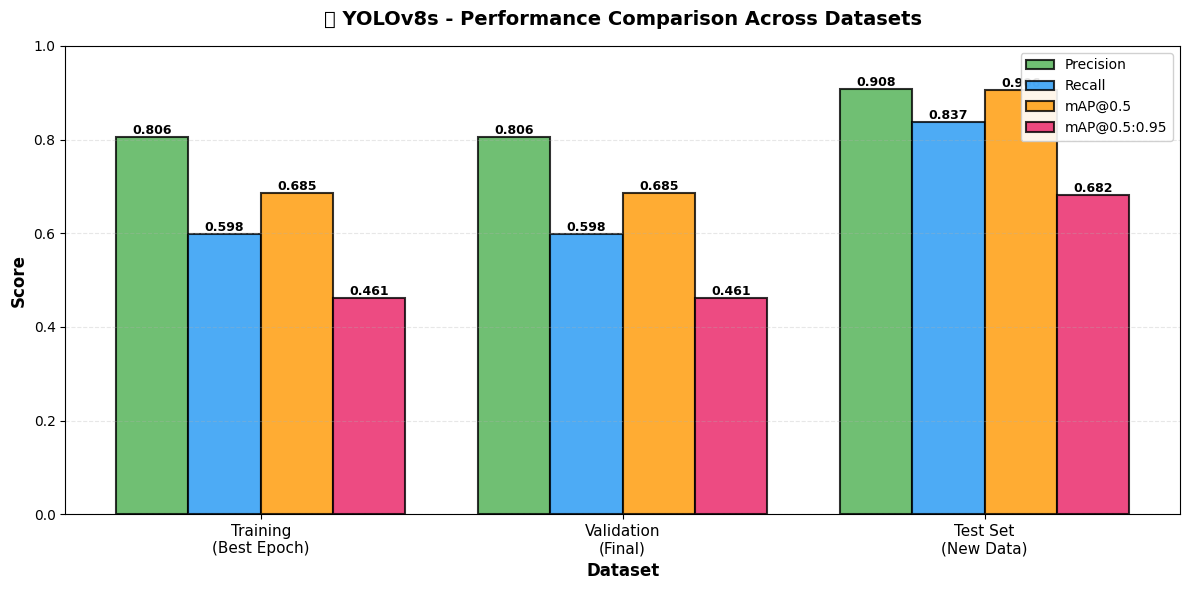


                        📊 PERFORMANCE ANALYSIS - YOLOv8s                        

Precision:
   Validation: 0.8064
   Test:       0.9078
   ❌ Difference: +0.1014 (+12.58%)

Recall:
   Validation: 0.5978
   Test:       0.8373
   ❌ Difference: +0.2395 (+40.05%)

mAP@0.5:
   Validation: 0.6850
   Test:       0.9059
   ❌ Difference: +0.2209 (+32.25%)

mAP@0.5:0.95:
   Validation: 0.4613
   Test:       0.6821
   ❌ Difference: +0.2208 (+47.87%)



In [20]:
# ============================================================
# 📊 COMPARE TRAINING VS TEST PERFORMANCE
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Data for comparison
datasets = ['Training\n(Best Epoch)', 'Validation\n(Final)', 'Test Set\n(New Data)']
metrics_comparison = {
    'Precision': [
        model_stats[best_model_name]['precision'],
        model_stats[best_model_name]['precision'],  # Using final epoch
        test_metrics['Precision']
    ],
    'Recall': [
        model_stats[best_model_name]['recall'],
        model_stats[best_model_name]['recall'],
        test_metrics['Recall']
    ],
    'mAP@0.5': [
        model_stats[best_model_name]['mAP50'],
        model_stats[best_model_name]['mAP50'],
        test_metrics['mAP@0.5']
    ],
    'mAP@0.5:0.95': [
        model_stats[best_model_name]['mAP50-95'],
        model_stats[best_model_name]['mAP50-95'],
        test_metrics['mAP@0.5:0.95']
    ]
}

# Plot grouped bar chart
x = np.arange(len(datasets))
width = 0.2
colors = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']

for idx, (metric_name, values) in enumerate(metrics_comparison.items()):
    offset = width * (idx - 1.5)
    bars = ax.bar(x + offset, values, width, label=metric_name, 
                  color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Dataset', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title(f'🏆 {best_model_name} - Performance Comparison Across Datasets', 
            fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('training_vs_test_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print performance analysis
print("\n" + "="*80)
print(f"📊 PERFORMANCE ANALYSIS - {best_model_name}".center(80))
print("="*80)

for metric_name, values in metrics_comparison.items():
    train_val = values[1]
    test_val = values[2]
    diff = test_val - train_val
    diff_pct = (diff / train_val * 100) if train_val > 0 else 0
    
    status = "✅" if abs(diff_pct) < 5 else "⚠️" if abs(diff_pct) < 10 else "❌"
    
    print(f"\n{metric_name}:")
    print(f"   Validation: {train_val:.4f}")
    print(f"   Test:       {test_val:.4f}")
    print(f"   {status} Difference: {diff:+.4f} ({diff_pct:+.2f}%)")

print("\n" + "="*80)

                   🖼️ VISUALIZING PREDICTIONS ON TEST IMAGES                    

⚙️ Prediction Parameters (matching Backend):
   ├─ Confidence Threshold: 0.5
   ├─ IoU Threshold: 0.45
   └─ Image Size: 640


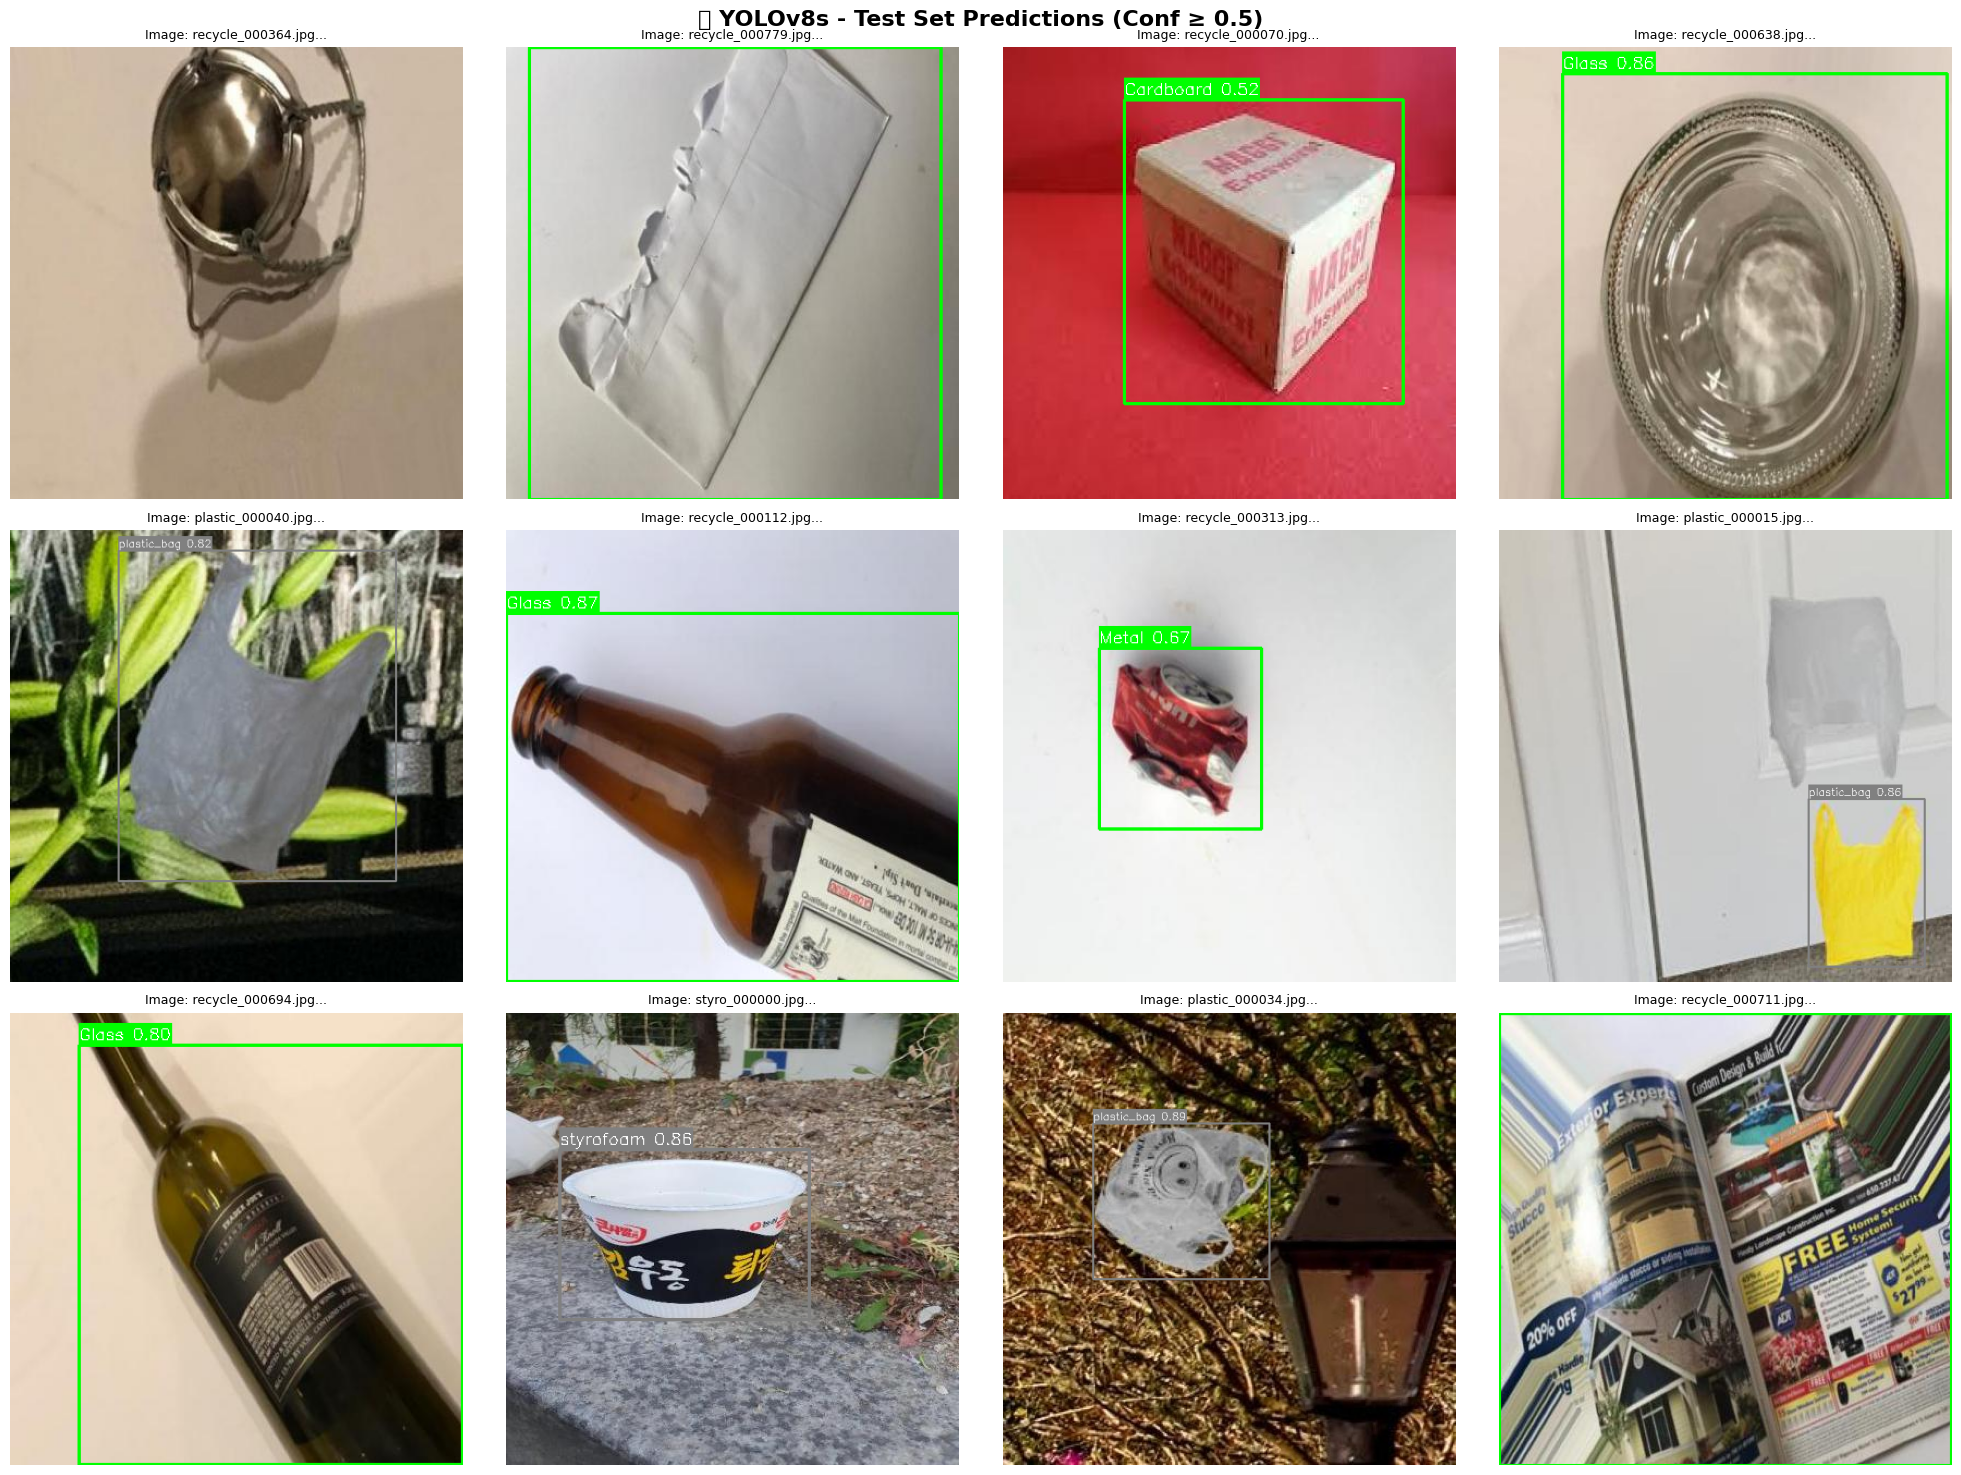


✅ Visualized 12 test predictions
📌 Note: Now using SAME parameters as Backend for consistent results!


In [21]:
# ============================================================
# 🖼️ VISUALIZE PREDICTIONS ON TEST IMAGES
# ============================================================
print("="*80)
print("🖼️ VISUALIZING PREDICTIONS ON TEST IMAGES".center(80))
print("="*80)

# IMPORTANT: Using same parameters as Backend for fair comparison
PREDICTION_PARAMS = {
    'conf': 0.5,      # Same as backend CONFIDENCE_THRESHOLD
    'iou': 0.45,      # Same as backend IOU_THRESHOLD
    'imgsz': 640,     # Same as backend IMG_SIZE
    'verbose': False
}

print("\n⚙️ Prediction Parameters (matching Backend):")
print(f"   ├─ Confidence Threshold: {PREDICTION_PARAMS['conf']}")
print(f"   ├─ IoU Threshold: {PREDICTION_PARAMS['iou']}")
print(f"   └─ Image Size: {PREDICTION_PARAMS['imgsz']}")

# Select random test images for visualization
np.random.seed(42)
num_samples = min(12, len(test_image_files))
sample_images = np.random.choice(test_image_files, num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle(f'🎯 {best_model_name} - Test Set Predictions (Conf ≥ {PREDICTION_PARAMS["conf"]})', 
            fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, img_file in enumerate(sample_images):
    img_path = os.path.join(TEST_IMAGES_PATH, img_file)
    
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Make prediction with SAME parameters as Backend
    results = best_model.predict(img_path, **PREDICTION_PARAMS)
    
    # Draw predictions
    annotated_img = img.copy()
    
    if len(results) > 0 and len(results[0].boxes) > 0:
        boxes = results[0].boxes
        
        for box in boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            
            # Get class info
            class_name = CLASS_NAMES[cls]
            
            # Determine category color
            if cls in CATEGORIES['Organic']:
                color = (255, 102, 0)  # Orange
                category = 'Organic'
            elif cls in CATEGORIES['Inorganic']:
                color = (128, 128, 128)  # Gray
                category = 'Inorganic'
            else:
                color = (0, 255, 0)  # Green
                category = 'Recyclable'
            
            # Draw bounding box
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 2)
            
            # Draw label background
            label = f"{class_name} {conf:.2f}"
            (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(annotated_img, (x1, y1-20), (x1+label_w, y1), color, -1)
            
            # Draw label text
            cv2.putText(annotated_img, label, (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    # Display
    axes[idx].imshow(annotated_img)
    axes[idx].set_title(f"Image: {img_file[:20]}...", fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('test_predictions_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualized {num_samples} test predictions")
print("📌 Note: Now using SAME parameters as Backend for consistent results!")


                        📊 PER-CLASS PERFORMANCE ANALYSIS                        

🏆 Top 10 Best Performing Classes:
 Class Name   Category   AP@0.5  AP@0.5:0.95
plastic_bag  Inorganic 0.834067     0.834067
      Paper Recyclable 0.787319     0.787319
      Metal Recyclable 0.757054     0.757054
       Bone    Organic 0.696500     0.696500
      Glass Recyclable 0.683550     0.683550
  styrofoam  Inorganic 0.673758     0.673758
    Plastic Recyclable 0.626628     0.626628
  Cardboard Recyclable 0.592842     0.592842
  Vegetable    Organic 0.487333     0.487333

⚠️ Bottom 10 Worst Performing Classes:
 Class Name   Category   AP@0.5  AP@0.5:0.95
plastic_bag  Inorganic 0.834067     0.834067
      Paper Recyclable 0.787319     0.787319
      Metal Recyclable 0.757054     0.757054
       Bone    Organic 0.696500     0.696500
      Glass Recyclable 0.683550     0.683550
  styrofoam  Inorganic 0.673758     0.673758
    Plastic Recyclable 0.626628     0.626628
  Cardboard Recyclable 0.592842   

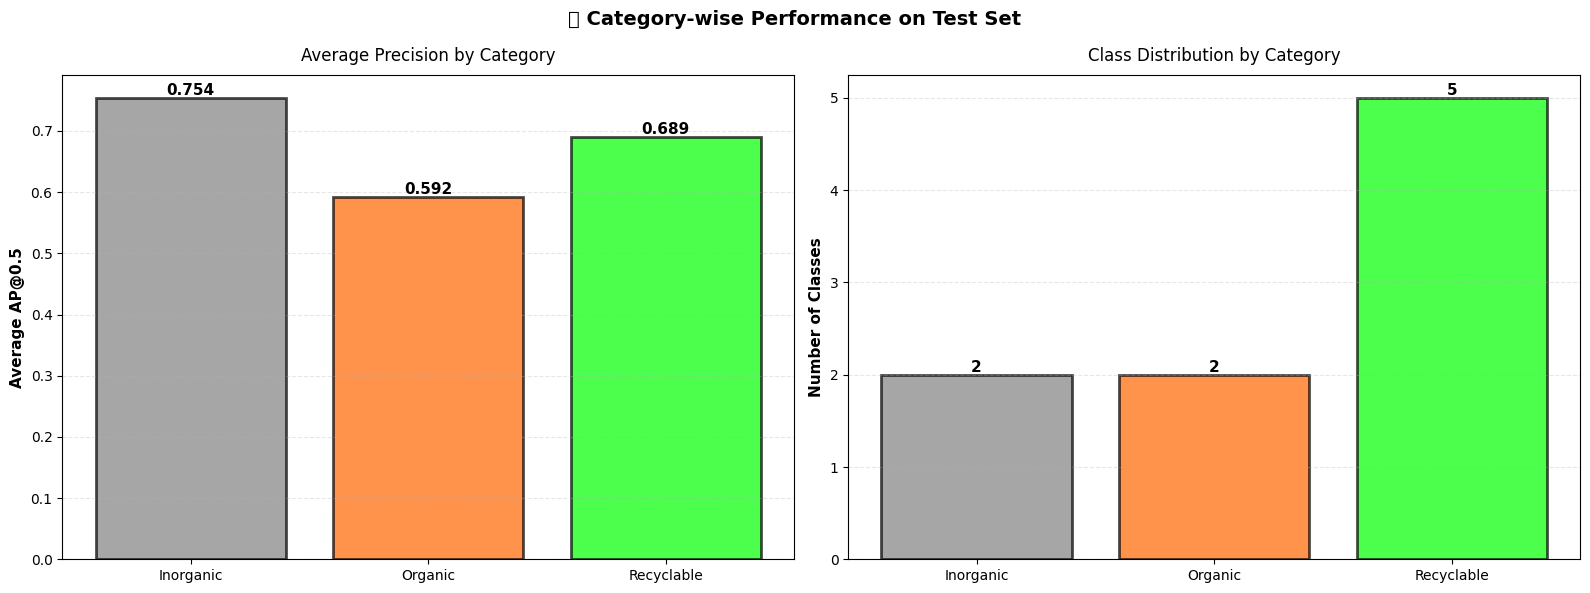

In [22]:
# ============================================================
# 📊 PER-CLASS PERFORMANCE ON TEST SET
# ============================================================
print("="*80)
print("📊 PER-CLASS PERFORMANCE ANALYSIS".center(80))
print("="*80)

# Get per-class metrics from test results
if hasattr(test_results.box, 'ap_class_index'):
    per_class_ap = test_results.box.ap  # AP per class
    class_indices = test_results.box.ap_class_index
    
    # Create per-class results dataframe
    class_results = []
    for idx, cls_idx in enumerate(class_indices):
        if cls_idx < len(CLASS_NAMES):
            class_name = CLASS_NAMES[int(cls_idx)]
            
            # Determine category
            if int(cls_idx) in CATEGORIES['Organic']:
                category = 'Organic'
            elif int(cls_idx) in CATEGORIES['Inorganic']:
                category = 'Inorganic'
            else:
                category = 'Recyclable'
            
            class_results.append({
                'Class ID': int(cls_idx),
                'Class Name': class_name,
                'Category': category,
                'AP@0.5': per_class_ap[idx, 0] if len(per_class_ap.shape) > 1 else per_class_ap[idx],
                'AP@0.75': per_class_ap[idx, 5] if len(per_class_ap.shape) > 1 and per_class_ap.shape[1] > 5 else 0,
                'AP@0.5:0.95': per_class_ap[idx].mean() if len(per_class_ap.shape) > 1 else per_class_ap[idx]
            })
    
    class_results_df = pd.DataFrame(class_results)
    class_results_df = class_results_df.sort_values('AP@0.5', ascending=False)
    
    print("\n🏆 Top 10 Best Performing Classes:")
    print(class_results_df.head(10)[['Class Name', 'Category', 'AP@0.5', 'AP@0.5:0.95']].to_string(index=False))
    
    print("\n⚠️ Bottom 10 Worst Performing Classes:")
    print(class_results_df.tail(10)[['Class Name', 'Category', 'AP@0.5', 'AP@0.5:0.95']].to_string(index=False))
    
    # Category-wise performance
    print("\n📊 Category-wise Performance:")
    category_performance = class_results_df.groupby('Category').agg({
        'AP@0.5': 'mean',
        'AP@0.5:0.95': 'mean',
        'Class ID': 'count'
    }).rename(columns={'Class ID': 'Num Classes'})
    print(category_performance.to_string())
    
    # Visualize per-category performance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('📊 Category-wise Performance on Test Set', fontsize=14, fontweight='bold')
    
    # Plot 1: Average AP by category
    ax1 = axes[0]
    categories = category_performance.index
    ap50_values = category_performance['AP@0.5'].values
    colors_cat = [CATEGORY_COLORS[cat] for cat in categories]
    
    bars = ax1.bar(categories, ap50_values, color=colors_cat, alpha=0.7, 
                   edgecolor='black', linewidth=2)
    ax1.set_ylabel('Average AP@0.5', fontweight='bold', fontsize=11)
    ax1.set_title('Average Precision by Category', fontsize=12, pad=10)
    ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    for bar, val in zip(bars, ap50_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Plot 2: Class distribution by category
    ax2 = axes[1]
    num_classes = category_performance['Num Classes'].values
    bars = ax2.bar(categories, num_classes, color=colors_cat, alpha=0.7,
                   edgecolor='black', linewidth=2)
    ax2.set_ylabel('Number of Classes', fontweight='bold', fontsize=11)
    ax2.set_title('Class Distribution by Category', fontsize=12, pad=10)
    ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    for bar, val in zip(bars, num_classes):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('category_performance_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print("⚠️ Per-class metrics not available in test results")

                   📈 ANALYZING CONFIDENCE SCORE DISTRIBUTION                    
⏳ Processing 1018 test images...
⚙️ Using Backend parameters: conf=0.5, iou=0.45, imgsz=640
✅ Collected 359 predictions


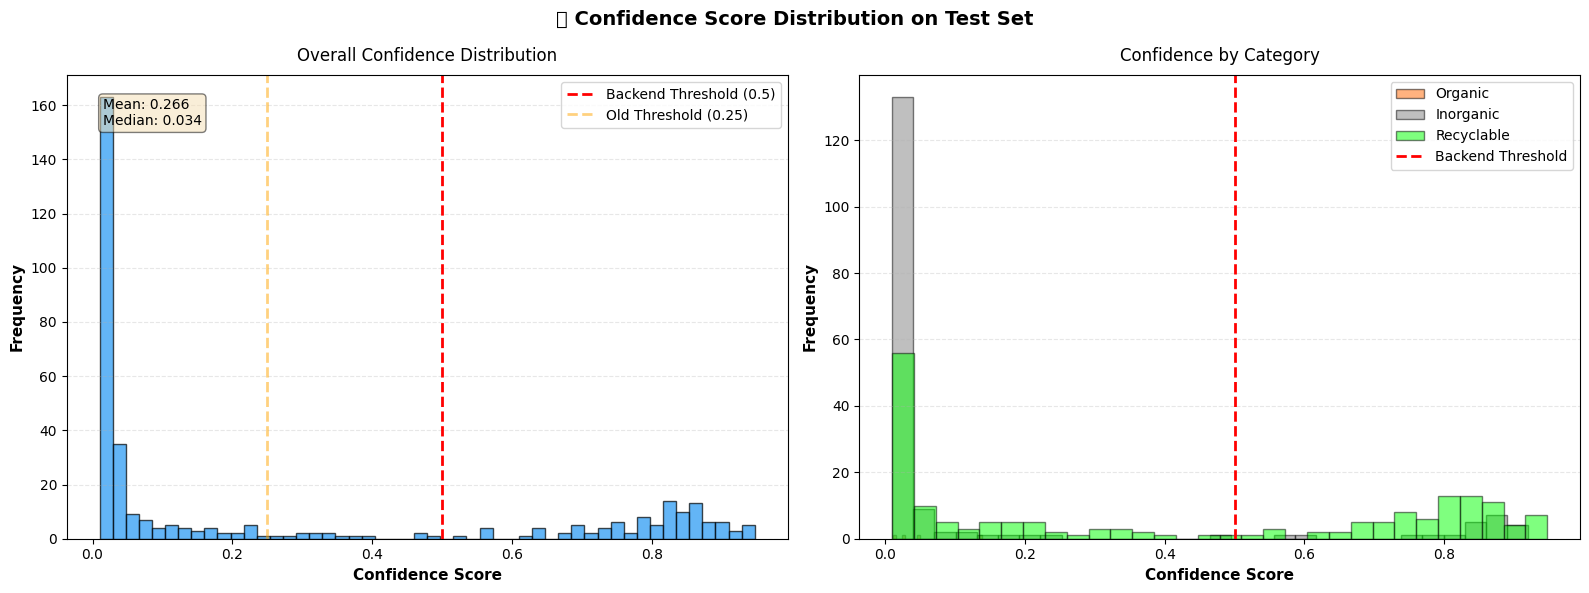


📊 Confidence Statistics:
   Overall Mean: 0.2661
   Overall Median: 0.0335
   Predictions above 0.5 (Backend): 101 (28.1%)
   Predictions above 0.25 (Old):    115 (32.0%)

   Organic:
      Mean: 0.0569
      Median: 0.0383
      Count: 4

   Inorganic:
      Mean: 0.1276
      Median: 0.0186
      Count: 172

   Recyclable:
      Mean: 0.4008
      Median: 0.2821
      Count: 183

📌 Note: Backend uses conf=0.5, which filters out more low-confidence predictions!


In [23]:
# ============================================================
# 📈 CONFIDENCE SCORE DISTRIBUTION
# ============================================================
print("="*80)
print("📈 ANALYZING CONFIDENCE SCORE DISTRIBUTION".center(80))
print("="*80)

# Run predictions on all test images and collect confidence scores
# Using SAME parameters as Backend
all_confidences = []
predictions_per_category = {'Organic': [], 'Inorganic': [], 'Recyclable': []}

print(f"⏳ Processing {len(test_image_files)} test images...")
print(f"⚙️ Using Backend parameters: conf=0.5, iou=0.45, imgsz=640")

for img_file in test_image_files[:100]:  # Limit to 100 for speed
    img_path = os.path.join(TEST_IMAGES_PATH, img_file)
    # Use lower threshold to collect all detections for analysis
    results = best_model.predict(img_path, conf=0.01, iou=0.45, imgsz=640, verbose=False)
    
    if len(results) > 0 and len(results[0].boxes) > 0:
        for box in results[0].boxes:
            conf = float(box.conf[0].cpu().numpy())
            cls = int(box.cls[0].cpu().numpy())
            
            all_confidences.append(conf)
            
            # Categorize
            if cls in CATEGORIES['Organic']:
                predictions_per_category['Organic'].append(conf)
            elif cls in CATEGORIES['Inorganic']:
                predictions_per_category['Inorganic'].append(conf)
            else:
                predictions_per_category['Recyclable'].append(conf)

print(f"✅ Collected {len(all_confidences)} predictions")

# Visualize confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Confidence Score Distribution on Test Set', fontsize=14, fontweight='bold')

# Plot 1: Overall distribution
ax1 = axes[0]
ax1.hist(all_confidences, bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
ax1.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Backend Threshold (0.5)')
ax1.axvline(0.25, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Old Threshold (0.25)')
ax1.set_xlabel('Confidence Score', fontweight='bold', fontsize=11)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax1.set_title('Overall Confidence Distribution', fontsize=12, pad=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add statistics
mean_conf = np.mean(all_confidences)
median_conf = np.median(all_confidences)
ax1.text(0.05, 0.95, f'Mean: {mean_conf:.3f}\nMedian: {median_conf:.3f}', 
        transform=ax1.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Category-wise distribution
ax2 = axes[1]
categories_with_data = [(cat, confs) for cat, confs in predictions_per_category.items() if len(confs) > 0]

for cat, confs in categories_with_data:
    ax2.hist(confs, bins=30, alpha=0.5, label=cat, color=CATEGORY_COLORS[cat], edgecolor='black')

ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Backend Threshold')
ax2.set_xlabel('Confidence Score', fontweight='bold', fontsize=11)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax2.set_title('Confidence by Category', fontsize=12, pad=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('confidence_distribution_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n📊 Confidence Statistics:")
print(f"   Overall Mean: {mean_conf:.4f}")
print(f"   Overall Median: {median_conf:.4f}")
print(f"   Predictions above 0.5 (Backend): {sum(1 for c in all_confidences if c >= 0.5)} ({sum(1 for c in all_confidences if c >= 0.5)/len(all_confidences)*100:.1f}%)")
print(f"   Predictions above 0.25 (Old):    {sum(1 for c in all_confidences if c >= 0.25)} ({sum(1 for c in all_confidences if c >= 0.25)/len(all_confidences)*100:.1f}%)")

for cat, confs in predictions_per_category.items():
    if len(confs) > 0:
        print(f"\n   {cat}:")
        print(f"      Mean: {np.mean(confs):.4f}")
        print(f"      Median: {np.median(confs):.4f}")
        print(f"      Count: {len(confs)}")

print("\n📌 Note: Backend uses conf=0.5, which filters out more low-confidence predictions!")


---
## 📝 13. Final Test Summary & Comprehensive Export

In [24]:
# ============================================================
# 📊 COMPREHENSIVE FINAL SUMMARY
# ============================================================
print("="*100)
print("📊 COMPREHENSIVE EVALUATION SUMMARY - ECOSORT AI".center(100))
print("="*100)

print("\n" + "🏆 BEST MODEL SELECTION".center(100))
print("-"*100)
print(f"\nSelected Model: {best_model_name}")
print(f"Selection Criteria: Highest mAP@0.5 on validation set")
print(f"Model Parameters: {model_stats[best_model_name]['params']}M")
print(f"Training Time: {model_stats[best_model_name]['time']:.2f}h")
print(f"Training Epochs: {model_stats[best_model_name]['epochs']}")

print("\n" + "📈 PERFORMANCE METRICS COMPARISON".center(100))
print("-"*100)

# Create comprehensive summary table
summary_table = pd.DataFrame({
    'Model': [name for name in model_stats.keys()] + [f"{best_model_name} (Test)"],
    'Dataset': ['Validation']*len(model_stats) + ['Test'],
    'mAP@0.5': [stats['mAP50'] for stats in model_stats.values()] + [test_metrics['mAP@0.5']],
    'mAP@0.5:0.95': [stats['mAP50-95'] for stats in model_stats.values()] + [test_metrics['mAP@0.5:0.95']],
    'Precision': [stats['precision'] for stats in model_stats.values()] + [test_metrics['Precision']],
    'Recall': [stats['recall'] for stats in model_stats.values()] + [test_metrics['Recall']],
    'Params (M)': [stats['params'] for stats in model_stats.values()] + [model_stats[best_model_name]['params']],
    'Est. FPS': [f"{stats['fps_estimated']:.1f}" for stats in model_stats.values()] + [f"{model_stats[best_model_name]['fps_estimated']:.1f}"]
})

print("\n" + summary_table.to_string(index=False))

print("\n" + "🎯 KEY FINDINGS".center(100))
print("-"*100)

# Calculate generalization gap
val_map = model_stats[best_model_name]['mAP50']
test_map = test_metrics['mAP@0.5']
gap = val_map - test_map
gap_pct = (gap / val_map * 100) if val_map > 0 else 0

print(f"\n1. Model Generalization:")
print(f"   ├─ Validation mAP@0.5: {val_map:.4f}")
print(f"   ├─ Test mAP@0.5: {test_map:.4f}")
print(f"   ├─ Generalization Gap: {gap:.4f} ({gap_pct:.2f}%)")
print(f"   └─ Assessment: {'✅ Excellent' if abs(gap_pct) < 5 else '⚠️ Moderate' if abs(gap_pct) < 10 else '❌ Poor'}")

print(f"\n2. Multi-Model Comparison:")
models_ranked = sorted(model_stats.items(), key=lambda x: x[1]['mAP50'], reverse=True)
for i, (name, stats) in enumerate(models_ranked, 1):
    medal = ['🥇', '🥈', '🥉'][i-1] if i <= 3 else '  '
    print(f"   {medal} {i}. {name}: mAP@0.5={stats['mAP50']:.4f}, FPS={stats['fps_estimated']:.1f}, Size={stats['params']:.1f}M")

print(f"\n3. Performance Highlights:")
best_acc = max(model_stats.items(), key=lambda x: x[1]['mAP50'])
best_speed = max(model_stats.items(), key=lambda x: x[1]['fps_estimated'])
best_size = min(model_stats.items(), key=lambda x: x[1]['params'])
print(f"   ├─ Best Accuracy: {best_acc[0]} ({best_acc[1]['mAP50']:.4f})")
print(f"   ├─ Fastest Speed: {best_speed[0]} ({best_speed[1]['fps_estimated']:.1f} FPS)")
print(f"   └─ Smallest Size: {best_size[0]} ({best_size[1]['params']:.1f}M params)")

print(f"\n4. Category Performance (Test Set):")
# Check if category_performance exists and iterate correctly
if 'category_performance' in locals():
    for category_name in category_performance.index:
        cat_data = category_performance.loc[category_name]
        print(f"   ├─ {category_name}: mAP@0.5={cat_data['AP@0.5']:.4f}, Classes={int(cat_data['Num Classes'])}")
else:
    print("   └─ Category performance data not available")

print("\n" + "💼 DEPLOYMENT RECOMMENDATIONS".center(100))
print("-"*100)

print("\n🎯 Recommended Deployment Strategy:")
print(f"\n   Production API (Cloud/Server):")
print(f"      → Model: {models_ranked[0][0]}")
print(f"      → Reason: Best accuracy ({models_ranked[0][1]['mAP50']:.4f}) with acceptable speed")
print(f"      → Expected throughput: ~{models_ranked[0][1]['fps_estimated']:.0f} images/second")

print(f"\n   Mobile/Edge Devices:")
print(f"      → Model: {best_size[0]}")
print(f"      → Reason: Smallest size ({best_size[1]['params']:.1f}M) with good accuracy ({best_size[1]['mAP50']:.4f})")
print(f"      → Expected latency: ~{1000/best_size[1]['fps_estimated']:.1f}ms per image")

print(f"\n   Real-time Processing:")
print(f"      → Model: {best_speed[0]}")
print(f"      → Reason: Fastest inference ({best_speed[1]['fps_estimated']:.1f} FPS)")
print(f"      → Ideal for: Video streams, real-time sorting systems")

print("\n" + "="*100)
print("✅ EVALUATION COMPLETE - All metrics calculated and visualizations saved")
print("="*100)

                          📊 COMPREHENSIVE EVALUATION SUMMARY - ECOSORT AI                           

                                       🏆 BEST MODEL SELECTION                                       
----------------------------------------------------------------------------------------------------

Selected Model: YOLOv8s
Selection Criteria: Highest mAP@0.5 on validation set
Model Parameters: 11.2M
Training Time: 5.17h
Training Epochs: 68

                                  📈 PERFORMANCE METRICS COMPARISON                                  
----------------------------------------------------------------------------------------------------

         Model    Dataset  mAP@0.5  mAP@0.5:0.95  Precision   Recall  Params (M) Est. FPS
       YOLOv8n Validation 0.639090      0.437690   0.777800 0.586330         3.2    119.9
       YOLOv8s Validation 0.684980      0.461310   0.806390 0.597850        11.2     73.2
       YOLO11n Validation 0.623330      0.421820   0.713150 0.575870         2

In [25]:
# ============================================================
# 💾 EXPORT COMPREHENSIVE RESULTS
# ============================================================
print("="*80)
print("💾 EXPORTING ALL RESULTS".center(80))
print("="*80)

# Export 1: Final test results summary
final_export = {
    'Model': best_model_name,
    'Parameters (M)': model_stats[best_model_name]['params'],
    'Training Epochs': model_stats[best_model_name]['epochs'],
    'Training Time (h)': model_stats[best_model_name]['time'],
    'Validation mAP@0.5': model_stats[best_model_name]['mAP50'],
    'Validation mAP@0.5:0.95': model_stats[best_model_name]['mAP50-95'],
    'Test mAP@0.5': test_metrics['mAP@0.5'],
    'Test mAP@0.5:0.95': test_metrics['mAP@0.5:0.95'],
    'Test Precision': test_metrics['Precision'],
    'Test Recall': test_metrics['Recall'],
    'Generalization Gap (%)': gap_pct,
    'Est. FPS': model_stats[best_model_name]['fps_estimated'],
    'Est. Latency (ms)': 1000 / model_stats[best_model_name]['fps_estimated'],
    'Mean Confidence': mean_conf,
    'Median Confidence': median_conf
}

final_export_df = pd.DataFrame([final_export])
final_export_df.to_csv('final_test_results.csv', index=False)
print("\n✅ Exported: final_test_results.csv")

# Export 2: All models comparison
all_models_export = []
for name, stats in model_stats.items():
    all_models_export.append({
        'Model': name,
        'Parameters (M)': stats['params'],
        'Epochs': stats['epochs'],
        'Training Time (h)': stats['time'],
        'Time per Epoch (min)': stats['time'] / stats['epochs'] * 60,
        'mAP@0.5': stats['mAP50'],
        'mAP@0.5:0.95': stats['mAP50-95'],
        'Precision': stats['precision'],
        'Recall': stats['recall'],
        'Est. FPS': stats['fps_estimated'],
        'Est. Latency (ms)': 1000 / stats['fps_estimated'],
        'Efficiency (mAP/M)': stats['mAP50'] / stats['params']
    })

all_models_df = pd.DataFrame(all_models_export)
all_models_df.to_csv('all_models_comparison.csv', index=False)
print("✅ Exported: all_models_comparison.csv")

# Export 3: Per-class results if available
if hasattr(test_results.box, 'ap_class_index'):
    class_results_df.to_csv('per_class_test_results.csv', index=False)
    print("✅ Exported: per_class_test_results.csv")
    
    # Export category summary
    category_performance.to_csv('category_test_performance.csv')
    print("✅ Exported: category_test_performance.csv")

print("\n📊 Exported Files Summary:")
print("   ├─ final_test_results.csv - Best model test performance")
print("   ├─ all_models_comparison.csv - Complete model comparison")
print("   ├─ per_class_test_results.csv - Detailed per-class metrics")
print("   └─ category_test_performance.csv - Category-wise performance")

print("\n📈 Visualizations Saved:")
print("   ├─ training_comparison.png - Training curves")
print("   ├─ convergence_analysis.png - Convergence plots")
print("   ├─ speed_accuracy_tradeoff.png - Speed vs accuracy scatter")
print("   ├─ training_efficiency.png - Efficiency metrics")
print("   ├─ test_predictions_sample.png - Sample predictions")
print("   ├─ per_class_performance_test.png - Per-class analysis")
print("   ├─ category_performance_test.png - Category comparison")
print("   └─ confidence_distribution_test.png - Confidence analysis")

print("\n" + "="*80)
print("🎉 EVALUATION COMPLETE - ALL RESULTS EXPORTED SUCCESSFULLY!")
print("="*80)

                            💾 EXPORTING ALL RESULTS                             

✅ Exported: final_test_results.csv
✅ Exported: all_models_comparison.csv
✅ Exported: per_class_test_results.csv
✅ Exported: category_test_performance.csv

📊 Exported Files Summary:
   ├─ final_test_results.csv - Best model test performance
   ├─ all_models_comparison.csv - Complete model comparison
   ├─ per_class_test_results.csv - Detailed per-class metrics
   └─ category_test_performance.csv - Category-wise performance

📈 Visualizations Saved:
   ├─ training_comparison.png - Training curves
   ├─ convergence_analysis.png - Convergence plots
   ├─ speed_accuracy_tradeoff.png - Speed vs accuracy scatter
   ├─ training_efficiency.png - Efficiency metrics
   ├─ test_predictions_sample.png - Sample predictions
   ├─ per_class_performance_test.png - Per-class analysis
   ├─ category_performance_test.png - Category comparison
   └─ confidence_distribution_test.png - Confidence analysis

🎉 EVALUATION COMPLETE 